# Projet Data Science — Formule 1

> **Source de données** : [FastF1](https://docs.fastf1.dev/) — API Python officielle pour les données F1  
> **Saisons couvertes** : 2018 – 2025 (sessions 2025 chargées si disponibles, fallback 2024 sinon)

---

## Sommaire

| # | Module | Méthode | Objectif |
|---|--------|---------|----------|
| 1 | [Non supervisé](#module-1) | Isolation Forest + DBSCAN | Détecter les anomalies en course |
| 2 | [Supervisé](#module-2) | Random Forest + XGBoost | Prédire le tour de pitstop |
| 3 | [Deep Learning](#module-3) | MLP PyTorch | Prédire le vainqueur |
| 4 | [NLP](#module-4) | HuggingFace Transformers | Analyser les radios pilote |

---

## ⚙️ Configuration & imports

In [1]:
%load_ext autoreload
%autoreload 2
# ↑ Recharge automatiquement les modules src/ à chaque cellule si le fichier change

import sys, warnings, time
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})

F1_RED   = '#E8002D'
F1_DARK  = '#15151E'
F1_GRAY  = '#6B6B6B'
F1_WHITE = '#FFFFFF'

print('✅ Environnement prêt')

✅ Environnement prêt


In [2]:
# ─── Paramètres globaux ───────────────────────────────────────────────────────
# Saisons analysées
SEASON_START = 2025
SEASON_END   = 2026

# Nombre max de manches par saison (None = toutes)
# Réduisez à 5-10 pour un chargement rapide en test
MAX_ROUNDS_PER_SEASON = None

# Époques pour le MLP
DL_EPOCHS = 50

print(f'Analyse : saisons {SEASON_START}–{SEASON_END}  |  Tous les GP disponibles')

Analyse : saisons 2025–2026  |  Tous les GP disponibles


---

## 📅 Calendrier & Prochain GP

In [3]:
from src.data_loader import list_events, get_next_gp

# Calendrier 2026
cal_2026 = list_events(SEASON_END)
cal_2025 = list_events(SEASON_START)

next_gp = get_next_gp(SEASON_END)

if next_gp:
    print(f"Prochain GP : {next_gp['EventName']}  ({next_gp['Year']})")
    print(f"Date estimée : {next_gp['EventDate']}")
    print(f"Manche n° {next_gp['RoundNumber']}")
else:
    print("Aucun GP futur trouvé — saison terminée ou calendrier non disponible")
    next_gp = {
        'RoundNumber': 0, 'EventName': 'Prochain GP', 'Country': '', 'Year': SEASON_END
    }

print(f"\nCalendrier {SEASON_END} :")
display(cal_2026)

Prochain GP : Canadian Grand Prix  (2026)
Date estimée : 2026-05-24 00:00:00
Manche n° 5

Calendrier 2026 :


,RoundNumber,EventName,Country,EventDate,EventFormat
0,1,Australian Grand Prix,Australia,2026-03-08,conventional
1,2,Chinese Grand Prix,China,2026-03-15,sprint_qualifying
2,3,Japanese Grand Prix,Japan,2026-03-29,conventional
3,4,Miami Grand Prix,United States,2026-05-03,sprint_qualifying
4,5,Canadian Grand Prix,Canada,2026-05-24,sprint_qualifying
5,6,Monaco Grand Prix,Monaco,2026-06-07,conventional
6,7,Barcelona Grand Prix,Spain,2026-06-14,conventional
7,8,Austrian Grand Prix,Austria,2026-06-28,conventional
8,9,British Grand Prix,United Kingdom,2026-07-05,sprint_qualifying
9,10,Belgian Grand Prix,Belgium,2026-07-19,conventional


---

## 📦 Chargement multi-saisons (2025 + 2026)

Le module `data_loader` centralise tous les accès à FastF1 avec cache local dans `data/cache/`.  
Les sessions 2026 non encore disputées sont silencieusement ignorées.

> ⏳ **Premier lancement** : environ 10 minutes selon la connexion (toutes les courses sont téléchargées puis mises en cache). Les exécutions suivantes sont instantanées.

In [4]:
from src.data_loader import (
    load_multiple_seasons, load_session,
    get_laps_features, get_weather, get_radio_messages,
)
import time

t0 = time.time()
print(f"Chargement de toutes les sessions {SEASON_START}–{SEASON_END}...")
print("(Les sessions futures ou indisponibles sont ignorées silencieusement)\n")

all_sessions = load_multiple_seasons(
    start=SEASON_START,
    end=SEASON_END,
    session_type='R',
    max_rounds=MAX_ROUNDS_PER_SEASON,
)

elapsed = time.time() - t0
print(f"\n{len(all_sessions)} sessions chargées en {elapsed:.0f}s")

# Résumé des sessions chargées
session_summary = []
for s in all_sessions:
    try:
        session_summary.append({
            'Année': int(s.date.year),
            'GP': s.event.get('EventName', '?'),
            'Manche': int(s.event.get('RoundNumber', 0)),
        })
    except Exception:
        pass

df_sessions_loaded = pd.DataFrame(session_summary)
if not df_sessions_loaded.empty:
    print(f"\nRépartition : {df_sessions_loaded.groupby('Année').size().to_dict()}")
    display(df_sessions_loaded)

# Session de référence = la plus récente (pour visualisations par course)
session = all_sessions[-1] if all_sessions else None
latest_session = session

if session:
    laps_df = get_laps_features(session)
    weather  = get_weather(session)
    event_name = session.event.get('EventName', '?')
    rainfall = weather["Rainfall"].astype(float).mean() if (
        not weather.empty and "Rainfall" in weather.columns
    ) else 0.0
    print(f"\nSession de référence (la plus récente) : {event_name} {session.date.year}")
    print(f"   Tours : {len(laps_df)}  |  Pilotes : {laps_df['Driver'].nunique()}")
else:
    laps_df  = pd.DataFrame()
    weather  = pd.DataFrame()
    event_name = "N/A"
    rainfall = 0.0
    print("Aucune session chargée — vérifiez la connexion internet.")

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count


Chargement de toutes les sessions 2025–2026...
(Les sessions futures ou indisponibles sont ignorées silencieusement)



req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '87'
core        WARNING 	Fixed incorrect tyre stint information for driver '30'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Driver 4 completed the race distance 00:00.022000 before the recorded end of the session.
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '1', '63', '12', '23', '18', '27', '16', '81', '44', '10', '22', '31', '87', '30', '5', '14', '55', '7', '6']
core           INFO 	Load


28 sessions chargées en 193s

Répartition : {2025: 24, 2026: 4}


,Année,GP,Manche
0,2025,Australian Grand Prix,1
1,2025,Chinese Grand Prix,2
2,2025,Japanese Grand Prix,3
3,2025,Bahrain Grand Prix,4
4,2025,Saudi Arabian Grand Prix,5
5,2025,Miami Grand Prix,6
6,2025,Emilia Romagna Grand Prix,7
7,2025,Monaco Grand Prix,8
8,2025,Spanish Grand Prix,9
9,2025,Canadian Grand Prix,10



Session de référence (la plus récente) : Miami Grand Prix 2026
   Tours : 1040  |  Pilotes : 22


In [5]:
# Aperçu du dataset de tours
laps_df.head(8)

,Driver,DriverNumber,LapNumber,LapTime_s,TyreLife,Compound,Stint,Position,SpeedST,SpeedFL,SpeedI1,SpeedI2,IsPersonalBest,TrackStatus,FreshTyre,PitInTime,PitOutTime,HasPitStop,LapTimeDelta
0,NOR,1,1.0,98.115,1.0,MEDIUM,1.0,3.0,298.0,273.0,213.0,183.0,False,1,True,NaT,NaT,False,5.333
1,NOR,1,2.0,92.770,2.0,MEDIUM,1.0,3.0,317.0,271.0,211.0,184.0,True,1,True,NaT,NaT,False,-0.012
2,NOR,1,3.0,93.263,3.0,MEDIUM,1.0,3.0,313.0,270.0,209.0,185.0,False,1,True,NaT,NaT,False,0.481
3,NOR,1,4.0,93.814,4.0,MEDIUM,1.0,3.0,310.0,273.0,205.0,186.0,False,1,True,NaT,NaT,False,1.032
4,NOR,1,5.0,93.842,5.0,MEDIUM,1.0,3.0,308.0,281.0,210.0,183.0,False,12,True,NaT,NaT,False,1.060
5,NOR,1,6.0,130.350,6.0,MEDIUM,1.0,2.0,98.0,249.0,84.0,108.0,False,24,True,NaT,NaT,False,37.568
6,NOR,1,7.0,137.842,7.0,MEDIUM,1.0,2.0,132.0,192.0,119.0,108.0,False,4,True,NaT,NaT,False,45.060
7,NOR,1,8.0,142.399,8.0,MEDIUM,1.0,2.0,110.0,240.0,108.0,97.0,False,4,True,NaT,NaT,False,49.617


---
<a id="module-1"></a>

## 🔍 Module 1 — Détection d'anomalies *(Non supervisé — 2025+2026)*

**Isolation Forest** + **DBSCAN** appliqués sur **toutes les sessions** chargées.  
Les anomalies représentent les tours avec comportements hors-norme : Safety Car, crashes, problèmes mécaniques.

Le graphique de droite montre le taux d'anomalies par GP sur l'ensemble de la saison.  
La timeline ci-dessous est tracée sur la **session de référence** (dernier GP disponible).

In [6]:
from src.unsupervised import (
    compare_models, plot_anomalies_timeline,
    plot_feature_distribution, print_anomaly_report,
    run_season_anomalies, plot_season_anomalies,
)

# ── Anomalies sur la session de référence (timeline)
t0 = time.time()
df_anomaly = compare_models(laps_df) if not laps_df.empty else pd.DataFrame()
print(f"Détection (session de référence) terminée en {time.time()-t0:.1f}s\n")
if not df_anomaly.empty:
    print_anomaly_report(df_anomaly)

# ── Analyse de toute la saison (peut prendre quelques minutes)
print(f"\nAnalyse anomalies sur {len(all_sessions)} sessions...")
t0 = time.time()
df_season_anom = run_season_anomalies(all_sessions)
print(f"Terminé en {time.time()-t0:.0f}s — {len(df_season_anom)} GP analysés")
display(df_season_anom.sort_values('IF_Rate', ascending=False).reset_index(drop=True))

Détection (session de référence) terminée en 0.2s


Analyse anomalies sur 28 sessions...


[unsupervised] Session ignorée : Found array with 0 sample(s) (shape=(0, 8)) while a minimum of 1 is required by StandardScaler.


Terminé en 4s — 27 GP analysés


,Circuit,Year,TotalLaps,IF_Anomalies,DBSCAN_Anomalies,Consensus,Validated,IF_Rate,DBSCAN_Rate
0,Singapore Grand Prix,2025,1229,61,1,1,1,5.0,0.1
1,United States Grand Prix,2025,1067,53,2,2,1,5.0,0.2
2,Chinese Grand Prix,2025,1065,52,3,3,1,4.9,0.3
3,Austrian Grand Prix,2025,1126,55,0,0,0,4.9,0.0
4,Monaco Grand Prix,2025,1425,70,2,2,1,4.9,0.1
5,Qatar Grand Prix,2025,1067,52,6,6,3,4.9,0.6
6,Abu Dhabi Grand Prix,2025,1156,57,2,2,0,4.9,0.2
7,Italian Grand Prix,2025,974,48,0,0,0,4.9,0.0
8,Hungarian Grand Prix,2025,1368,67,0,0,0,4.9,0.0
9,Japanese Grand Prix,2025,1059,52,1,0,0,4.9,0.1


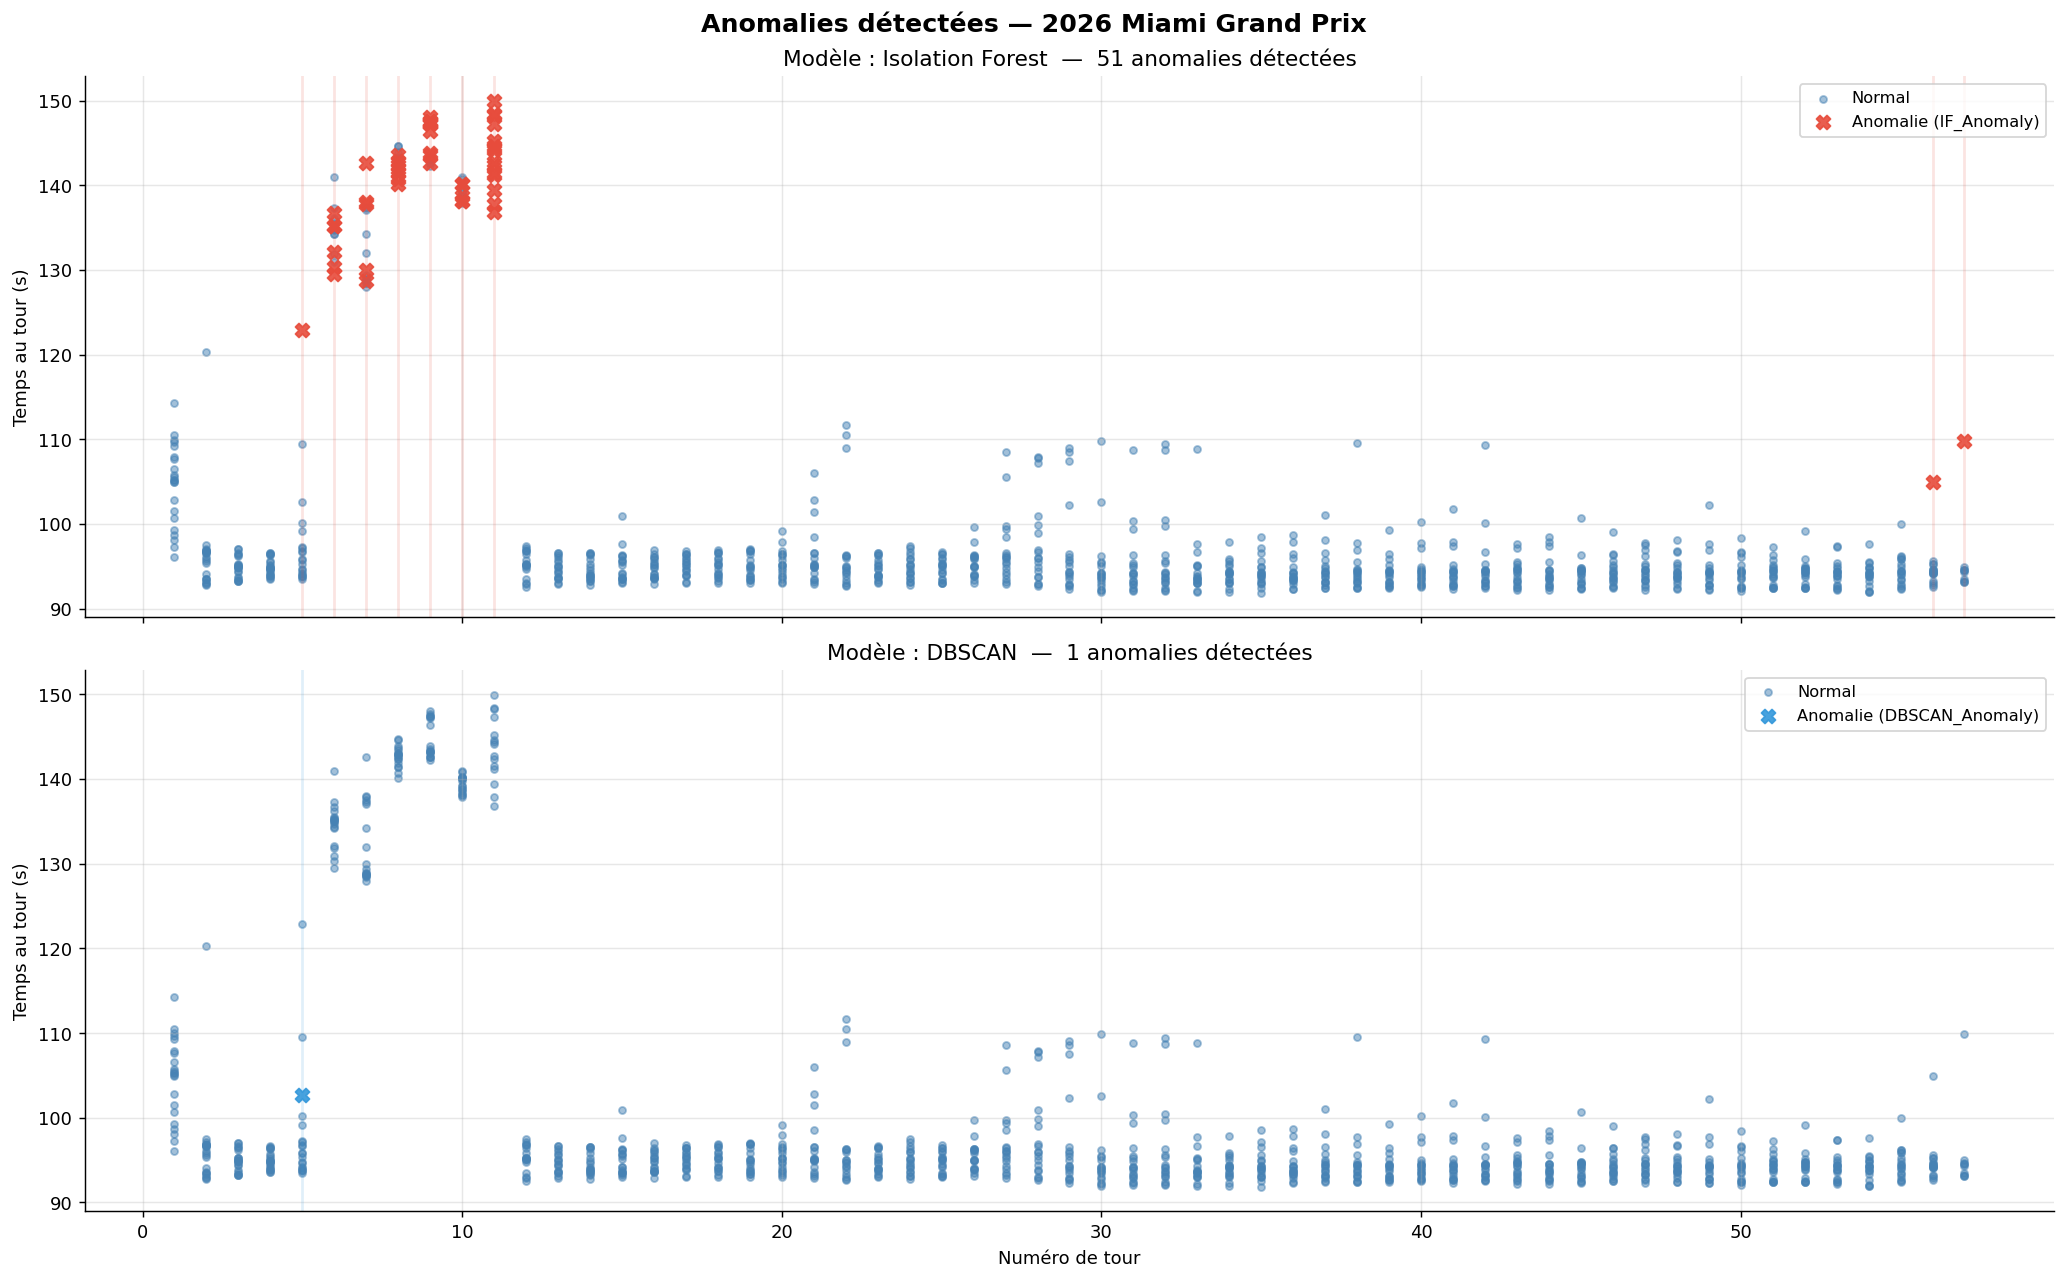

In [7]:
if not df_anomaly.empty:
    fig = plot_anomalies_timeline(
        df_anomaly,
        title=f'Anomalies détectées — {session.date.year} {event_name}'
    )
    plt.show()
else:
    print("Aucune donnée d'anomalie disponible pour la session de référence.")

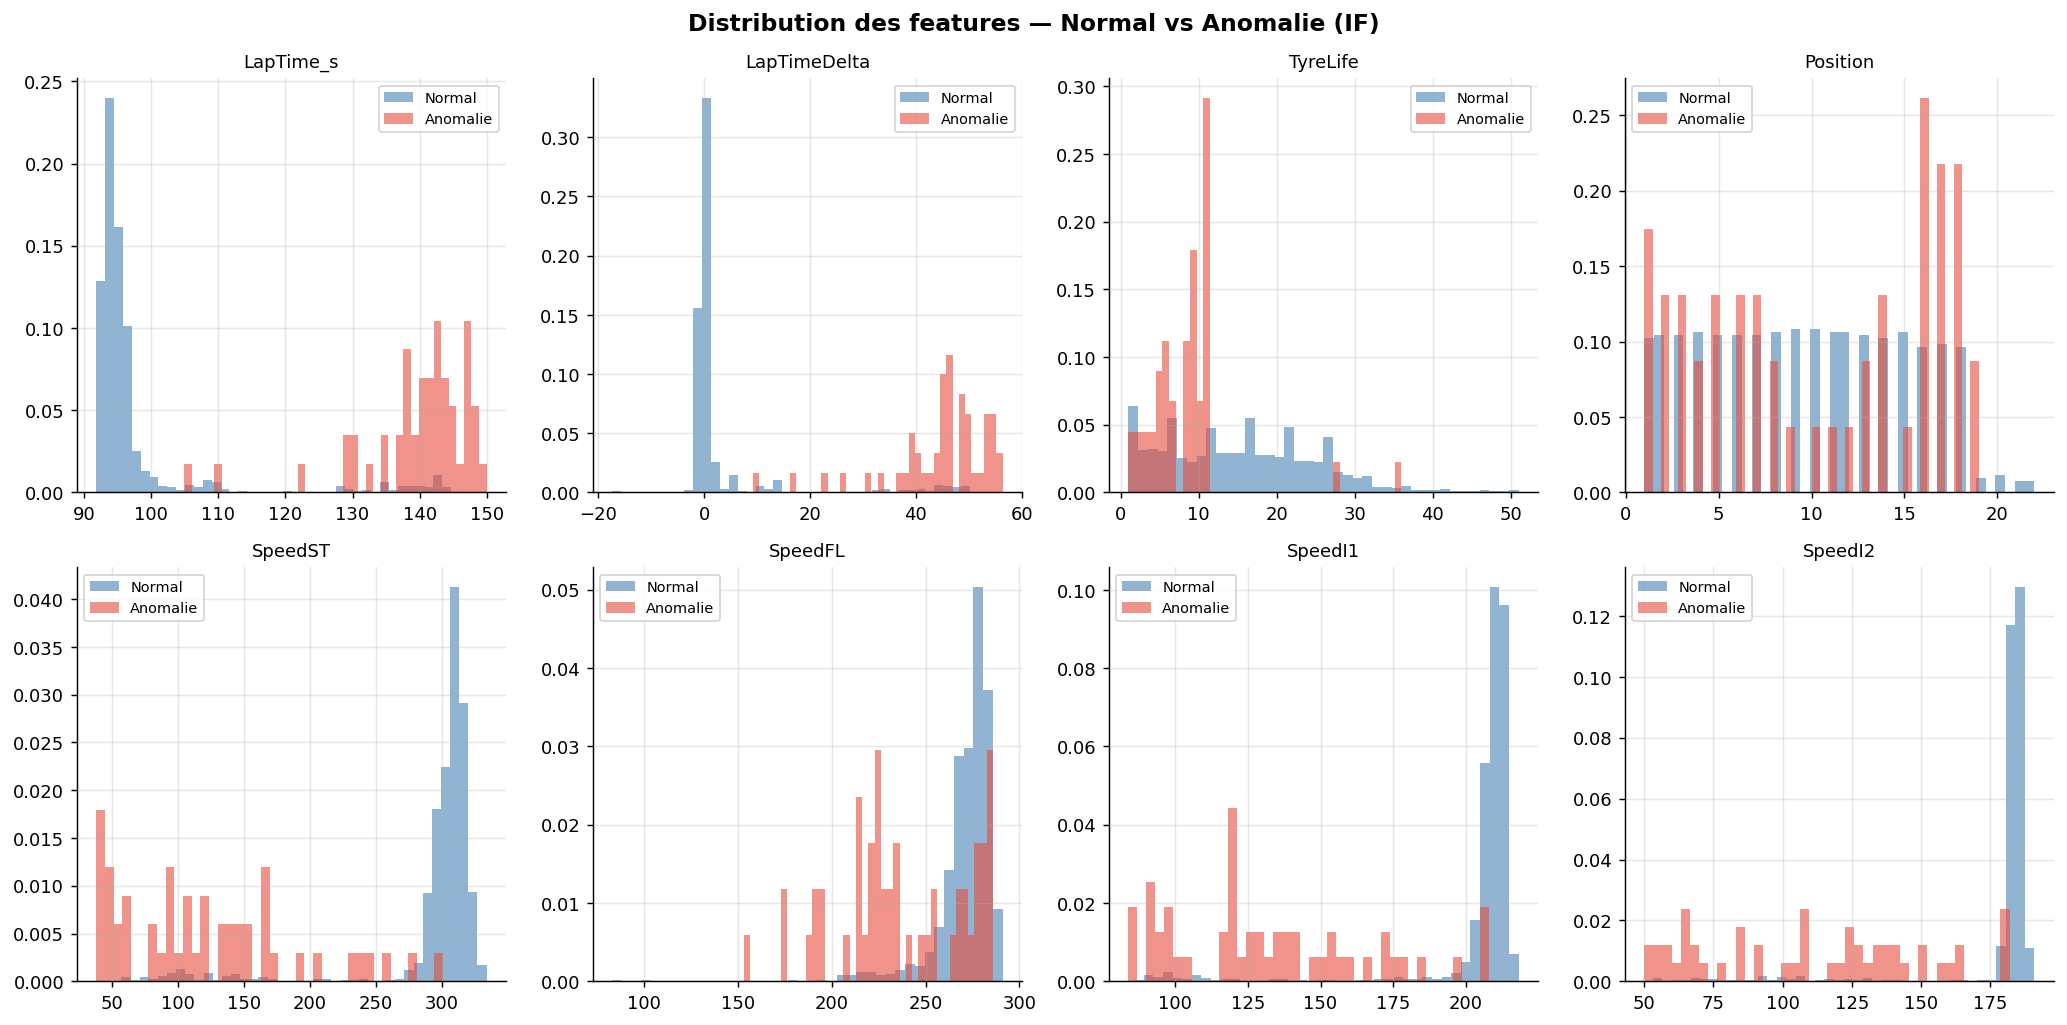

In [8]:
fig = plot_feature_distribution(df_anomaly)
plt.show()

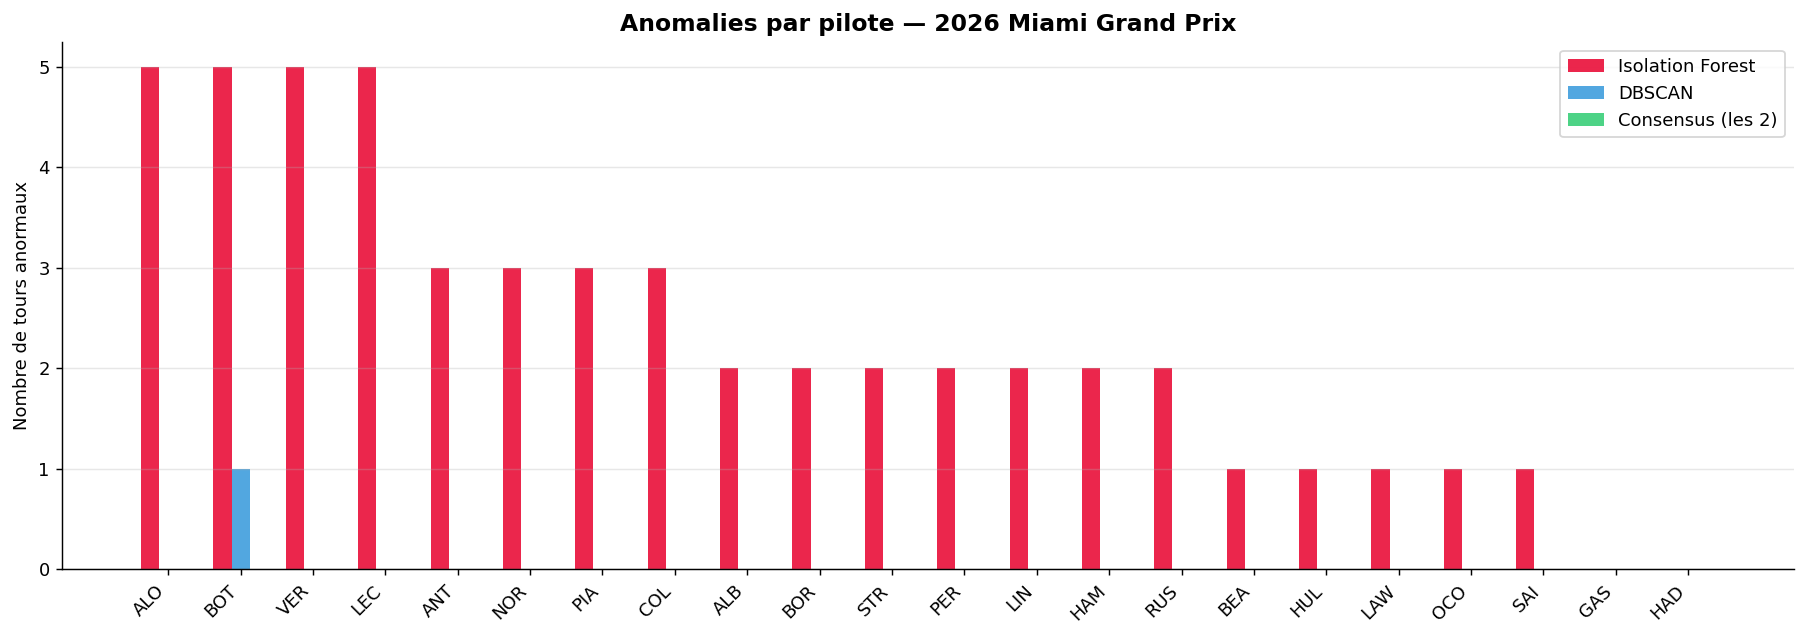

In [9]:
if df_anomaly.empty:
    print("Aucune donnée d'anomalie.")
else:
    # Anomalies par pilote — comparaison IF vs DBSCAN
    driver_anom = (
        df_anomaly.groupby('Driver')[['IF_Anomaly', 'DBSCAN_Anomaly', 'Both_Anomaly']]
        .sum().sort_values('IF_Anomaly', ascending=False)
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    x = np.arange(len(driver_anom))
    ax.bar(x - 0.25, driver_anom['IF_Anomaly'],    width=0.25, label='Isolation Forest', color=F1_RED,   alpha=0.85)
    ax.bar(x,        driver_anom['DBSCAN_Anomaly'], width=0.25, label='DBSCAN',           color='#3498db', alpha=0.85)
    ax.bar(x + 0.25, driver_anom['Both_Anomaly'],   width=0.25, label='Consensus (les 2)', color='#2ecc71', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(driver_anom.index, rotation=45, ha='right')
    ax.set_ylabel('Nombre de tours anormaux')
    ax.set_title(f'Anomalies par pilote — {session.date.year} {event_name}', fontweight='bold', fontsize=13)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [10]:
# Correspondance avec le statut de piste (Safety Car, VSC, etc.)
if 'TrackStatus' in df_anomaly.columns:
    status_map = {'1': 'Normal', '2': 'Yellow', '4': 'Safety Car', '6': 'Virtual SC', '7': 'Red Flag'}
    df_anomaly['StatusLabel'] = df_anomaly['TrackStatus'].astype(str).map(status_map).fillna('Autre')
    
    taux = (
        df_anomaly.groupby('StatusLabel')['IF_Anomaly']
        .agg(lambda x: f"{100*x.mean():.0f}% ({x.sum()}/{len(x)})")
        .rename('Taux détection IF')
    )
    print('Taux de détection par statut de piste (Isolation Forest) :')
    display(taux.to_frame())
else:
    print('TrackStatus non disponible pour cette session.')

Taux de détection par statut de piste (Isolation Forest) :


,Taux détection IF
StatusLabel,
Autre,20% (21/107)
Normal,0% (0/852)
Safety Car,37% (30/81)


### Métriques — Module 1

In [11]:
# Métriques session de référence
if not df_anomaly.empty:
    metrics_unsup = {
        'total_laps'          : len(df_anomaly),
        'if_anomalies'        : int(df_anomaly['IF_Anomaly'].sum()),
        'dbscan_anomalies'    : int(df_anomaly['DBSCAN_Anomaly'].sum()),
        'consensus_anomalies' : int(df_anomaly['Both_Anomaly'].sum()),
        'if_rate_pct'         : round(100 * df_anomaly['IF_Anomaly'].mean(), 1),
    }
else:
    metrics_unsup = {'total_laps': 0, 'if_anomalies': 0, 'dbscan_anomalies': 0,
                     'consensus_anomalies': 0, 'if_rate_pct': 0.0}

pd.DataFrame([metrics_unsup]).T.rename(columns={0: 'Valeur'})

,Valeur
total_laps,1040.0
if_anomalies,51.0
dbscan_anomalies,1.0
consensus_anomalies,0.0
if_rate_pct,4.9


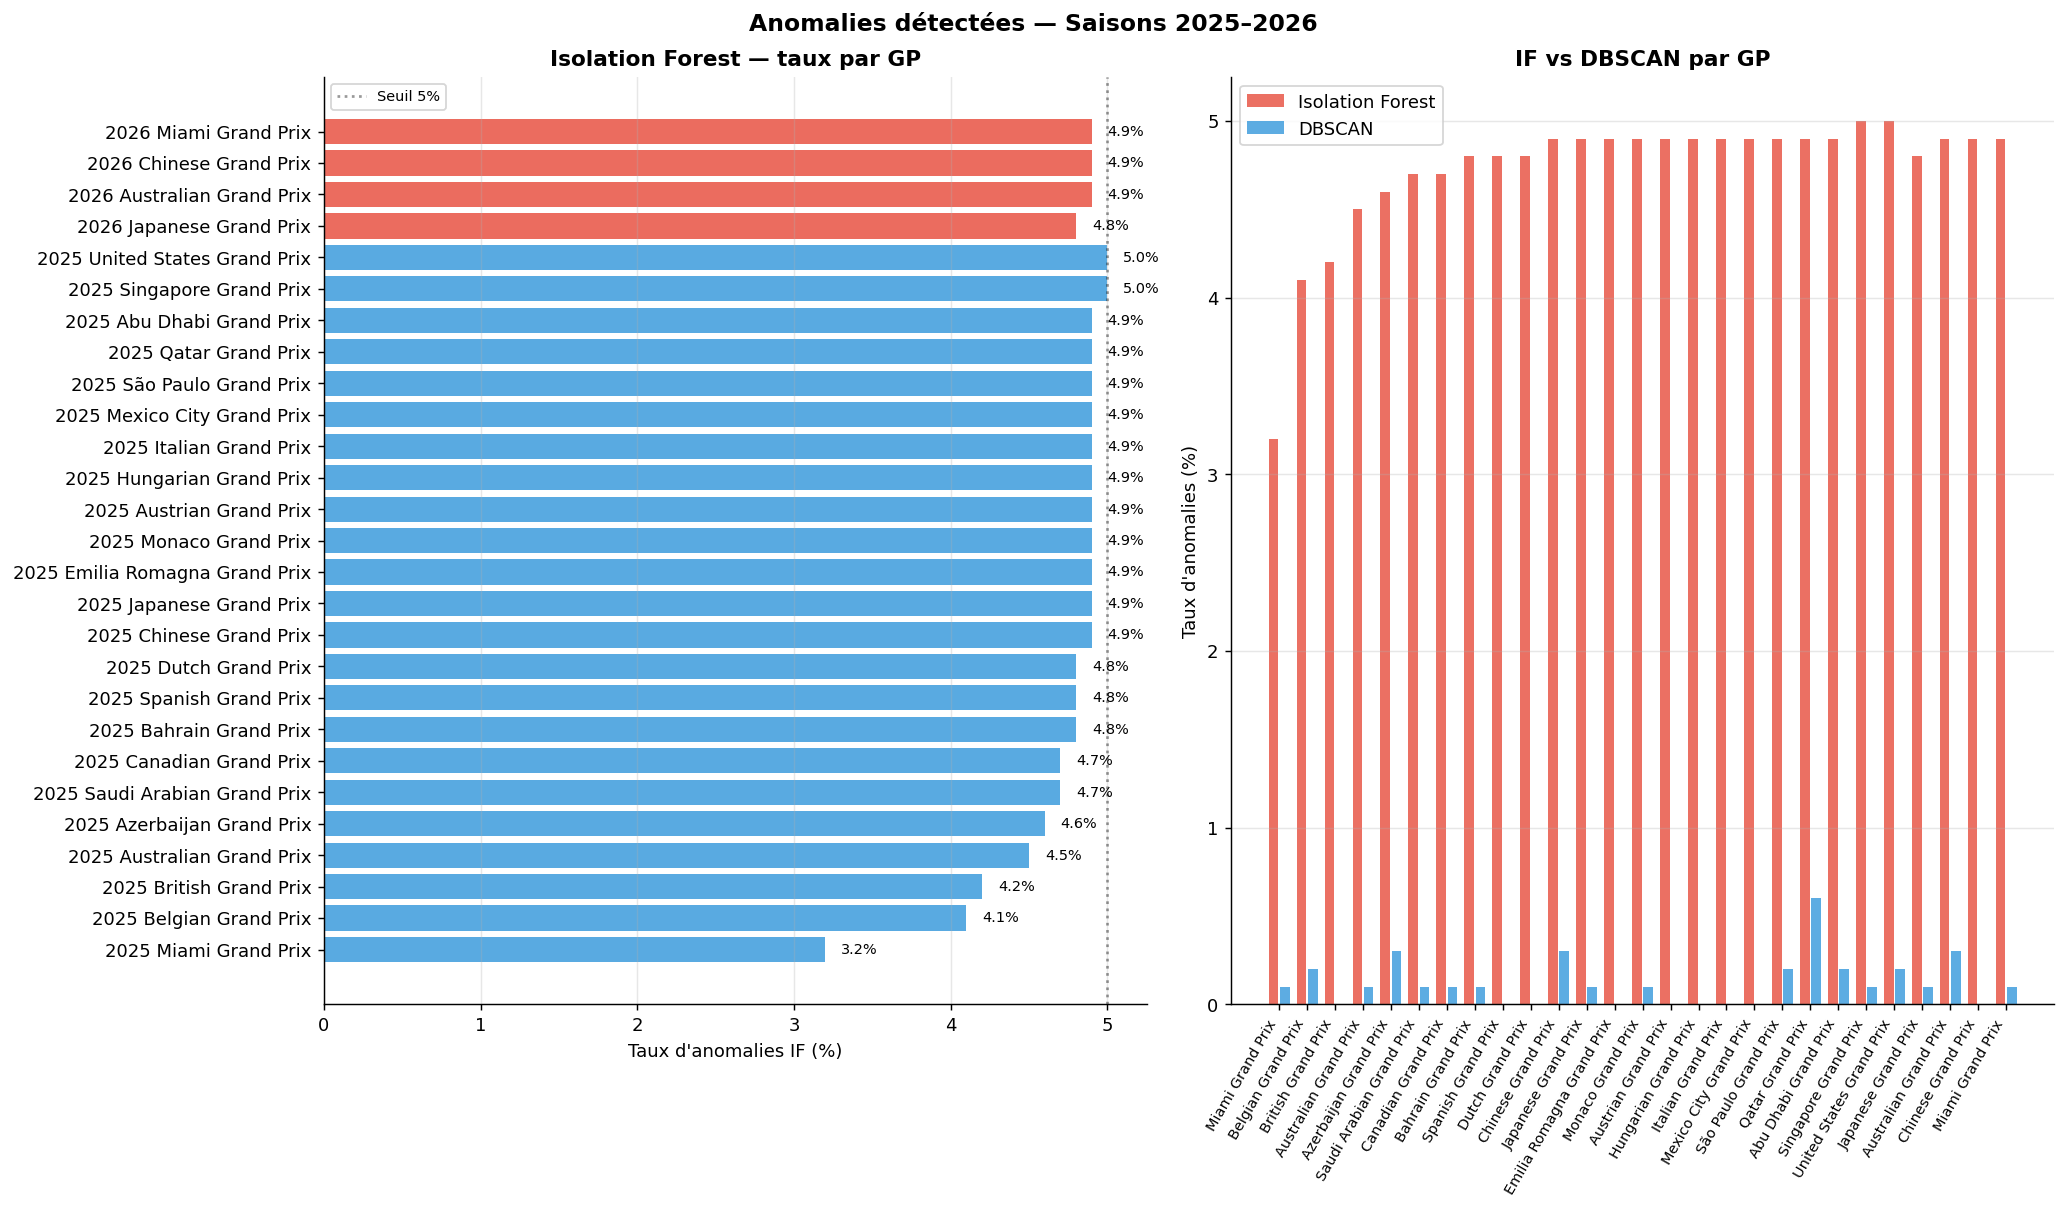

  2025 — IF moyen : 4.7%  |  GP le plus perturbé : Singapore Grand Prix (5.0%)
  2026 — IF moyen : 4.9%  |  GP le plus perturbé : Australian Grand Prix (4.9%)


In [12]:
# Visualisation des anomalies sur toute la saison
if not df_season_anom.empty:
    fig_season_anom = plot_season_anomalies(df_season_anom)
    plt.show()
    
    # Taux moyen par saison
    for year, grp in df_season_anom.groupby('Year'):
        avg_rate = grp['IF_Rate'].mean()
        max_gp   = grp.loc[grp['IF_Rate'].idxmax(), 'Circuit']
        print(f"  {year} — IF moyen : {avg_rate:.1f}%  |  GP le plus perturbé : {max_gp} ({grp['IF_Rate'].max():.1f}%)")

In [13]:
# Prédiction d'anomalies pour le prochain GP
# On identifie le circuit le plus similaire dans l'historique
if not df_season_anom.empty and next_gp:
    next_circuit = next_gp['EventName']
    # Recherche exacte puis approximative
    match = df_season_anom[df_season_anom['Circuit'] == next_circuit]
    if match.empty:
        match = df_season_anom[df_season_anom['Circuit'].str.contains(
            next_circuit.split()[0], case=False, na=False)]
    
    overall_avg = df_season_anom['IF_Rate'].mean()
    print(f"=== Prévision anomalies — {next_gp['Year']} {next_circuit} ===")
    if not match.empty:
        historical_rate = match['IF_Rate'].mean()
        print(f"  Taux historique sur ce circuit : {historical_rate:.1f}%")
    else:
        historical_rate = overall_avg
        print(f"  Taux moyen saison (circuit non encore couru) : {overall_avg:.1f}%")
    print(f"  Taux attendu       : ~{historical_rate:.1f}%")

=== Prévision anomalies — 2026 Canadian Grand Prix ===
  Taux historique sur ce circuit : 4.7%
  Taux attendu       : ~4.7%


---
<a id="module-2"></a>

## 🎯 Module 2 — Prédiction du pitstop *(Supervisé — 2025+2026)*

Modèles **RF + XGBoost** entraînés sur **l'ensemble des saisons 2025-2026** disponibles.  
**Split temporel** : les dernières sessions constituent le test set (pas de data leakage).  
En fin de section : **prévision de la fenêtre de pitstop pour le prochain GP**.

In [14]:
from sklearn.model_selection import train_test_split
from src.supervised import (
    build_dataset, prepare_Xy, _temporal_split,
    train_random_forest, train_xgboost,
    evaluate_model, plot_confusion_matrix,
    plot_feature_importance, plot_model_comparison,
    predict_next_gp_pitstops, plot_pitstop_forecast,
    HAS_XGB,
)

print(f'XGBoost disponible : {HAS_XGB}')
print(f'Construction du dataset sur {len(all_sessions)} sessions...')

# Dataset complet 2025+2026
t0 = time.time()
df_sup = build_dataset(all_sessions)
print(f'Dataset supervisé : {len(df_sup)} tours en {time.time()-t0:.0f}s')
print(f'Pitstops          : {df_sup["HasPitStop"].sum()} ({100*df_sup["HasPitStop"].mean():.1f}%)')
print(f'Sessions couvertes: {df_sup["SessionIdx"].nunique()}')

XGBoost disponible : True
Construction du dataset sur 28 sessions...
Dataset supervisé : 30762 tours en 0s
Pitstops          : 949 (3.1%)
Sessions couvertes: 28


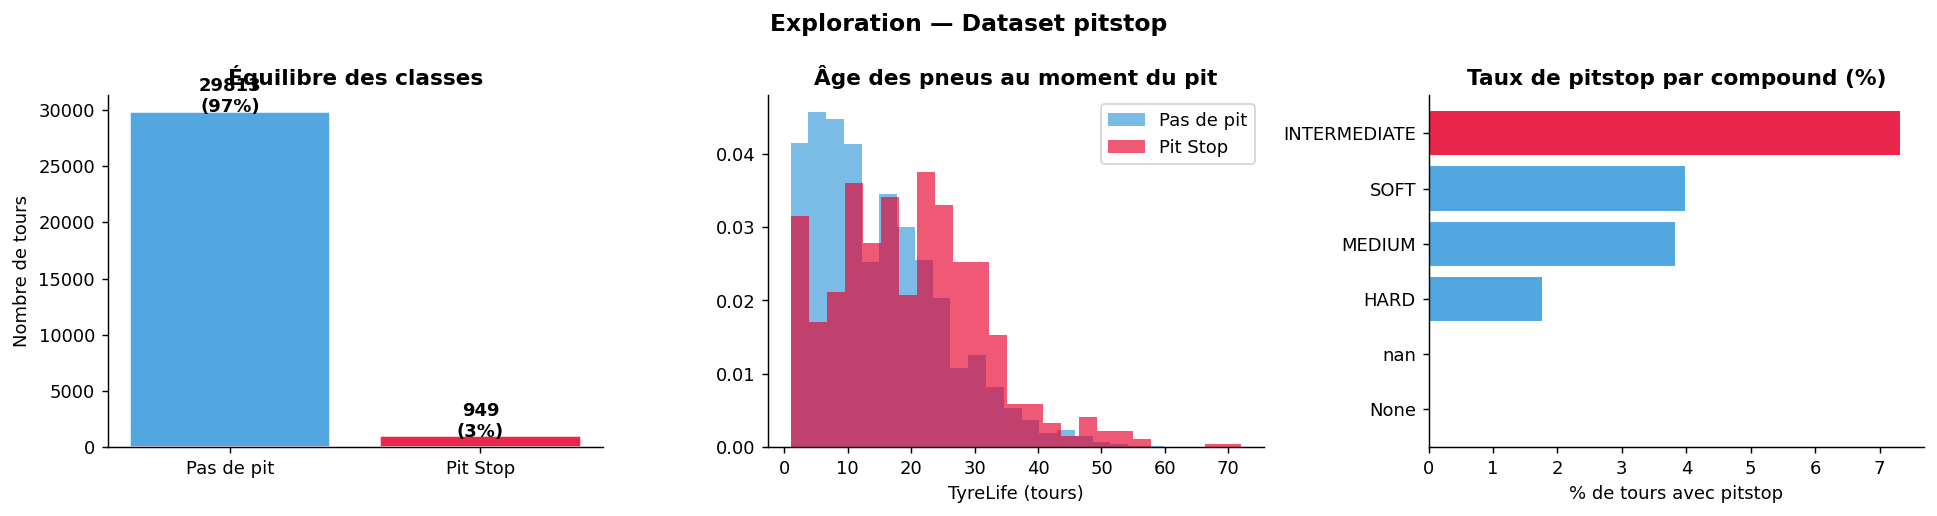

In [15]:
# Visualisation de l'équilibre des classes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

counts = df_sup['HasPitStop'].value_counts()
axes[0].bar(['Pas de pit', 'Pit Stop'], counts.values,
            color=['#3498db', F1_RED], alpha=0.85, edgecolor='white')
axes[0].set_title('Équilibre des classes', fontweight='bold')
axes[0].set_ylabel('Nombre de tours')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, f'{v}\n({100*v/len(df_sup):.0f}%)', ha='center', fontweight='bold')

for label, grp in df_sup.groupby('HasPitStop'):
    color = F1_RED if label else '#3498db'
    axes[1].hist(grp['TyreLife'].dropna(), bins=25, alpha=0.65,
                 label='Pit Stop' if label else 'Pas de pit',
                 color=color, density=True)
axes[1].set_title('Âge des pneus au moment du pit', fontweight='bold')
axes[1].set_xlabel('TyreLife (tours)')
axes[1].legend()

if 'Compound' in df_sup.columns:
    pit_by_comp = (df_sup.groupby('Compound')['HasPitStop'].mean() * 100).sort_values(ascending=True)
    colors_comp = [F1_RED if v > 5 else '#3498db' for v in pit_by_comp.values]
    axes[2].barh(pit_by_comp.index, pit_by_comp.values, color=colors_comp, alpha=0.85)
    axes[2].set_title('Taux de pitstop par compound (%)', fontweight='bold')
    axes[2].set_xlabel('% de tours avec pitstop')

plt.suptitle('Exploration — Dataset pitstop', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
X, y = prepare_Xy(df_sup)
# Split temporel : les derniers tours servent de test pour éviter le data leakage
X_train, X_test, y_train, y_test = _temporal_split(df_sup, X, y, test_size=0.2)
print(f'Split temporel — Train : {len(X_train)}  |  Test : {len(X_test)}')
print(f'Features : {X.columns.tolist()}')

Split temporel — Train : 24466  |  Test : 6296
Features : ['TyreLife', 'Compound_enc', 'Position', 'LapNumber', 'Stint', 'LapTimeDelta_prev', 'SpeedST', 'SpeedFL', 'FreshTyre', 'Rainfall']


In [17]:
rf_model, rf_params = train_random_forest(X_train, y_train)
metrics_rf = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

In [18]:
metrics_xgb = None
xgb_model = None

if HAS_XGB:
    xgb_model, xgb_params = train_xgboost(X_train, y_train)
    if xgb_model:
        metrics_xgb = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

In [19]:
# Consolidation des métriques supervisées (utilisées dans le dashboard)
metrics_sup = {
    'RF — Accuracy' : round(metrics_rf['accuracy'], 4),
    'RF — F1-Score' : round(metrics_rf['f1'], 4),
}
if metrics_xgb:
    metrics_sup['XGB — Accuracy'] = round(metrics_xgb['accuracy'], 4)
    metrics_sup['XGB — F1-Score'] = round(metrics_xgb['f1'], 4)

pd.DataFrame([metrics_sup]).T.rename(columns={0: 'Valeur'})

,Valeur
RF — Accuracy,1.0000
RF — F1-Score,1.0000
XGB — Accuracy,0.9989
XGB — F1-Score,0.9808


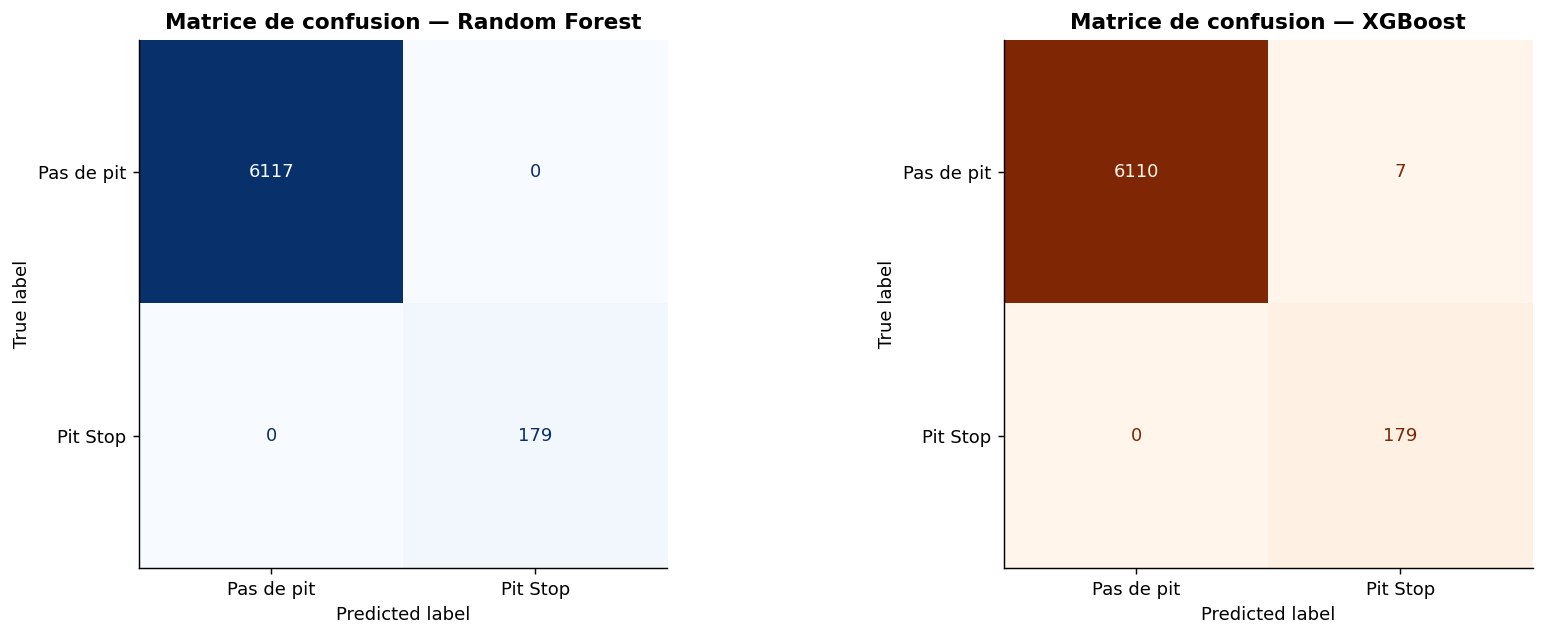

In [20]:
# Matrices de confusion côte à côte
n_models = 2 if (xgb_model and metrics_xgb) else 1
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 5))
if n_models == 1:
    axes = [axes]

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test, metrics_rf['y_pred'],
    display_labels=['Pas de pit', 'Pit Stop'],
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Matrice de confusion — Random Forest', fontweight='bold')

if n_models == 2:
    ConfusionMatrixDisplay.from_predictions(
        y_test, metrics_xgb['y_pred'],
        display_labels=['Pas de pit', 'Pit Stop'],
        ax=axes[1], colorbar=False, cmap='Oranges'
    )
    axes[1].set_title('Matrice de confusion — XGBoost', fontweight='bold')

plt.tight_layout()
plt.show()

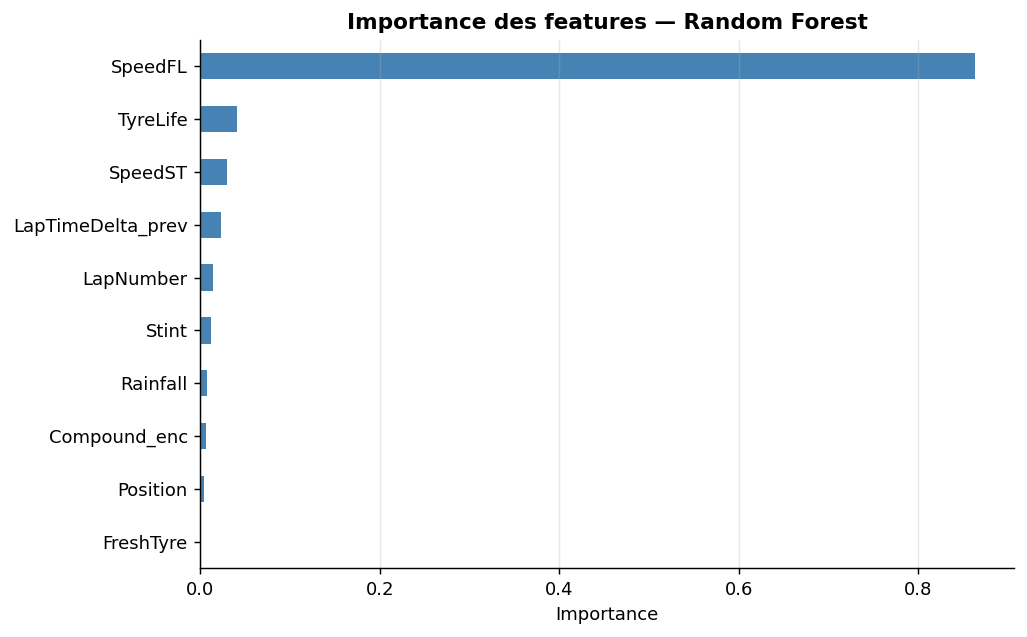

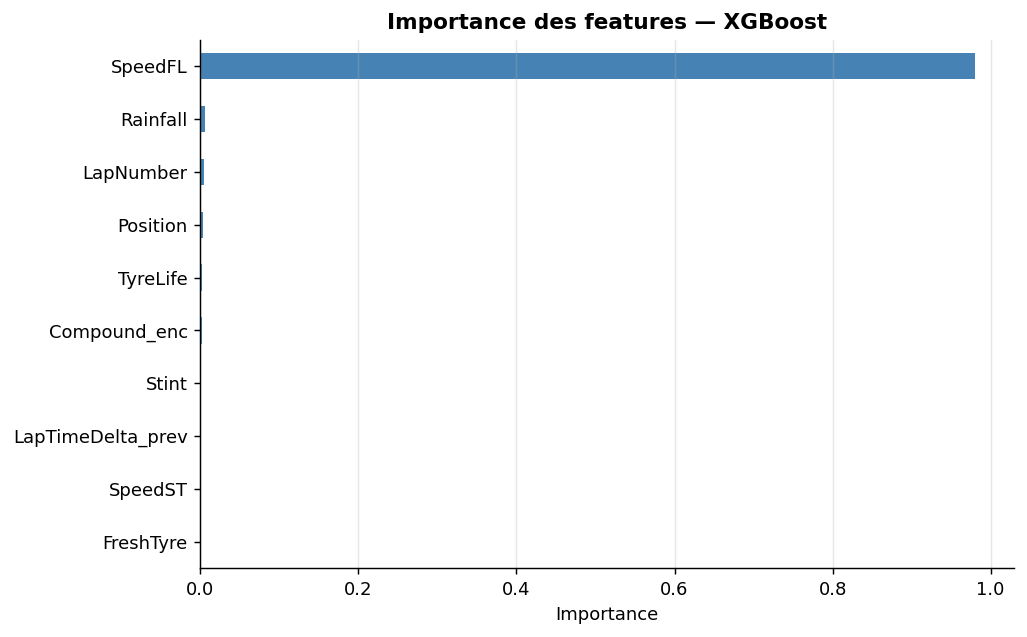

In [21]:
# Importance des features
fig = plot_feature_importance(rf_model, X.columns.tolist(), 'Random Forest')
plt.show()

if xgb_model:
    fig = plot_feature_importance(xgb_model, X.columns.tolist(), 'XGBoost')
    plt.show()

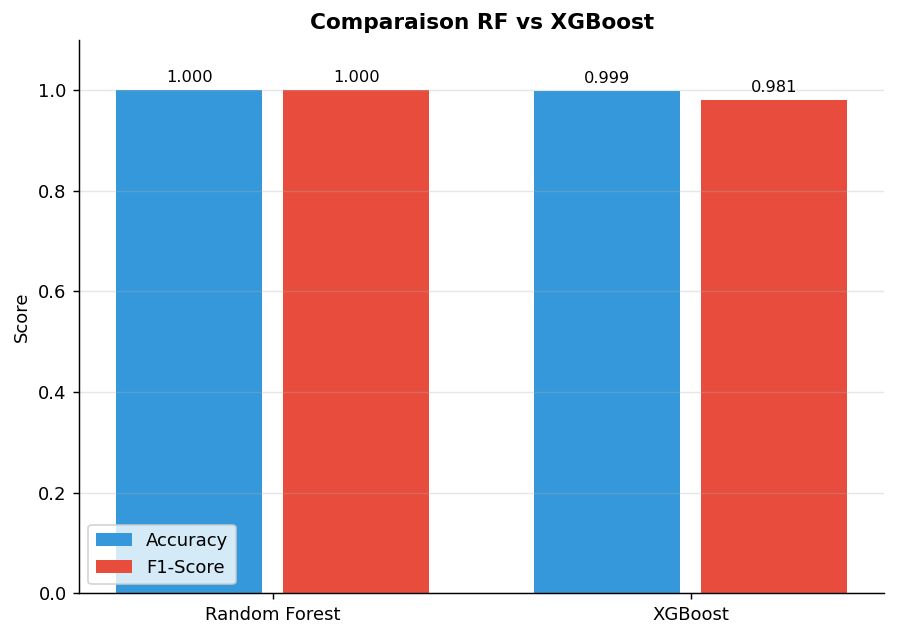

In [22]:
fig = plot_model_comparison(metrics_rf, metrics_xgb)
plt.show()

=== Prévision pitstops — 2026 Canadian Grand Prix ===
Nombre de tours estimé : 78
Modèle entraîné sur 28 sessions 2025–2026

Fenêtre de pitstop recommandée (P cumulée ≥ 50%) à la position P10 :
  SOFT    : tours 23 → 78
  MEDIUM  : tours 26 → 78
  HARD    : tours 28 → 78


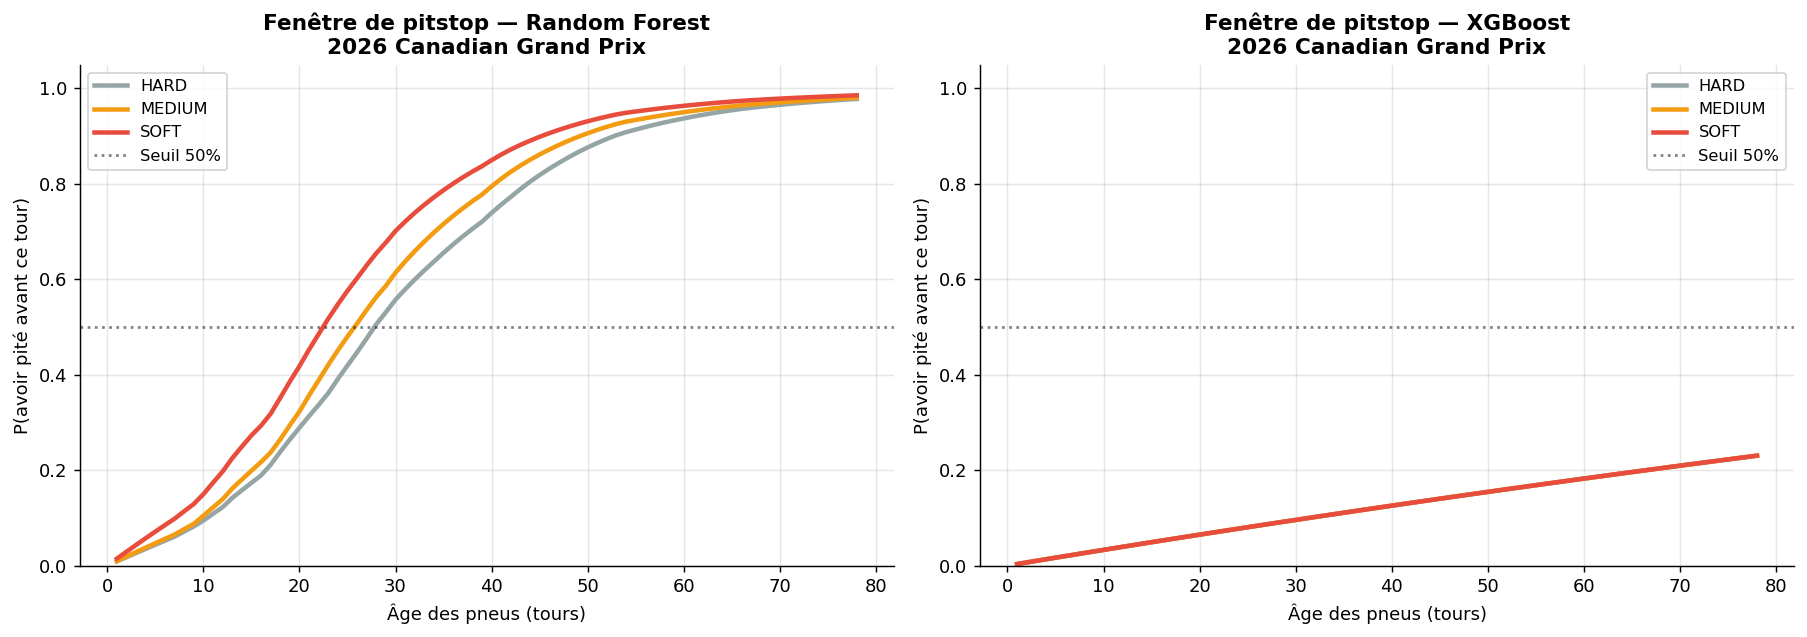

In [23]:
# Nombre de tours estimé pour le prochain GP (utilise le max des sessions précédentes)
n_laps_estimate = int(df_sup['LapNumber'].max()) if not df_sup.empty else 58
n_laps_estimate = max(40, min(80, n_laps_estimate))

print(f"=== Prévision pitstops — {next_gp['Year']} {next_gp['EventName']} ===")
print(f"Nombre de tours estimé : {n_laps_estimate}")
print(f"Modèle entraîné sur {len(all_sessions)} sessions 2025–2026\n")

df_pit_forecast = predict_next_gp_pitstops(
    rf_model, xgb_model if HAS_XGB else None, next_gp, n_laps=n_laps_estimate
)

# Fenêtre de pitstop optimale par compound — seuil 50% sur probabilité cumulée
# (P(avoir pité avant le tour t) ≥ 50% = fenêtre attendue par le modèle)
cum_col = 'CumPitProba_RF' if 'CumPitProba_RF' in df_pit_forecast.columns else 'PitProba_RF'
print(f"Fenêtre de pitstop recommandée (P cumulée ≥ 50%) à la position P10 :")
df_p10 = df_pit_forecast[df_pit_forecast['Position'] == 10]
compound_order = {'SOFT': 1, 'MEDIUM': 2, 'HARD': 3}
for compound in sorted(df_p10['Compound'].unique(), key=lambda c: compound_order.get(c, 9)):
    g = df_p10[df_p10['Compound'] == compound]
    mask_50 = g[cum_col] >= 0.5
    win_lap = g[mask_50]['TyreLife'].min() if mask_50.any() else float('nan')
    if not np.isnan(win_lap):
        max_lap = g[mask_50]['TyreLife'].max()
        print(f"  {compound:8s}: tours {int(win_lap)} → {int(max_lap)}")
    else:
        print(f"  {compound:8s}: probabilité cumulée < 50% sur toute la course")

fig_pit = plot_pitstop_forecast(df_pit_forecast, next_gp)
plt.show()

### Métriques — Module 2

---
<a id="module-3"></a>

## 🧠 Module 3 — Deep Learning : Prédiction du vainqueur *(2025+2026)*

MLP (128→64→32→1) — He init, CosineAnnealingLR, MC Dropout N=50.

In [24]:
from src.deep_learning import (
    build_race_dataset, prepare_Xy as dl_prepare_Xy,
    train_mlp, top_k_accuracy,
    plot_learning_curve, plot_top_predictions,
    predict_winner_next_gp, plot_winner_forecast,
    WinnerMLP, HAS_TORCH,
)

print(f'PyTorch disponible : {HAS_TORCH}')
if HAS_TORCH:
    import torch
    print(f'Version           : {torch.__version__}')
    print(f'CUDA              : {torch.cuda.is_available()}')

PyTorch disponible : True
Version           : 2.10.0+cpu
CUDA              : False


In [25]:
# Dataset DL = toutes les sessions 2025-2026 (mêmes sessions que les autres modules)
print(f"Construction du dataset DL sur {len(all_sessions)} sessions...")
t0 = time.time()
df_dl = build_race_dataset(all_sessions)
print(f"Dataset : {len(df_dl)} entrées pilote/course en {time.time()-t0:.0f}s")
print(f"Vainqueurs : {df_dl['IsWinner'].sum()}  ({100*df_dl['IsWinner'].mean():.1f}%)")
display(df_dl.head(8))

Construction du dataset DL sur 28 sessions...
Dataset : 567 entrées pilote/course en 0s
Vainqueurs : 28  (4.9%)


,Driver,Year,Circuit,GridPosition,FinishPosition,Points,Team,Rainfall,AvgRecentPos,StdRecentPos,AvgCircuitPos,IsWinner
0,NOR,2025,Australian Grand Prix,1.0,1.0,25.0,McLaren,0.325843,10.0,5.0,10.0,1
1,VER,2025,Australian Grand Prix,3.0,2.0,18.0,Red Bull Racing,0.325843,10.0,5.0,10.0,0
2,RUS,2025,Australian Grand Prix,4.0,3.0,15.0,Mercedes,0.325843,10.0,5.0,10.0,0
3,ANT,2025,Australian Grand Prix,16.0,4.0,12.0,Mercedes,0.325843,10.0,5.0,10.0,0
4,ALB,2025,Australian Grand Prix,6.0,5.0,10.0,Williams,0.325843,10.0,5.0,10.0,0
5,STR,2025,Australian Grand Prix,13.0,6.0,8.0,Aston Martin,0.325843,10.0,5.0,10.0,0
6,HUL,2025,Australian Grand Prix,17.0,7.0,6.0,Kick Sauber,0.325843,10.0,5.0,10.0,0
7,LEC,2025,Australian Grand Prix,7.0,8.0,4.0,Ferrari,0.325843,10.0,5.0,10.0,0


In [26]:
X_dl, y_dl, dl_features = dl_prepare_Xy(df_dl)
print(f'Features ({len(dl_features)}) : {dl_features}')
print(f'Shape X : {X_dl.shape}  |  Shape y : {y_dl.shape}')

# Split temporel au niveau des courses (évite la contamination train/test)
# Un split aléatoire par pilote place des pilotes d'une même course dans train ET test,
# ce qui permet au modèle d'inférer le résultat depuis ses coéquipiers → top-K artificiellement parfait.
sorted_races = sorted(df_dl.groupby(['Year', 'Circuit']).groups.keys())
n_test_races = max(1, int(len(sorted_races) * 0.2))
test_races = set(sorted_races[-n_test_races:])

test_mask = pd.Series([
    (row['Year'], row['Circuit']) in test_races
    for _, row in df_dl.iterrows()
]).values
idx_te = np.where(test_mask)[0]
idx_tr = np.where(~test_mask)[0]

X_te, y_te = X_dl[idx_te], y_dl[idx_te]

from sklearn.model_selection import train_test_split as _tts
X_tr, X_val, y_tr, y_val = _tts(X_dl[idx_tr], y_dl[idx_tr], test_size=0.15, random_state=42)

print(f'Split race-level — Train: {len(X_tr)}  Val: {len(X_val)}  Test: {len(X_te)}')
print(f'Courses test ({n_test_races}) : {[f"{y} {c[:20]}" for y, c in sorted(test_races)]}')

Features (6) : ['GridPosition', 'AvgRecentPos', 'StdRecentPos', 'AvgCircuitPos', 'Rainfall', 'Team_enc']
Shape X : (567, 6)  |  Shape y : (567,)
Split race-level — Train: 390  Val: 69  Test: 108
Courses test (5) : ['2025 United States Grand ', '2026 Australian Grand Pri', '2026 Chinese Grand Prix', '2026 Japanese Grand Prix', '2026 Miami Grand Prix']


In [27]:
dl_model, dl_history = train_mlp(
    X_tr, y_tr, X_val, y_val,
    epochs=DL_EPOCHS, lr=1e-3, batch_size=32,
)

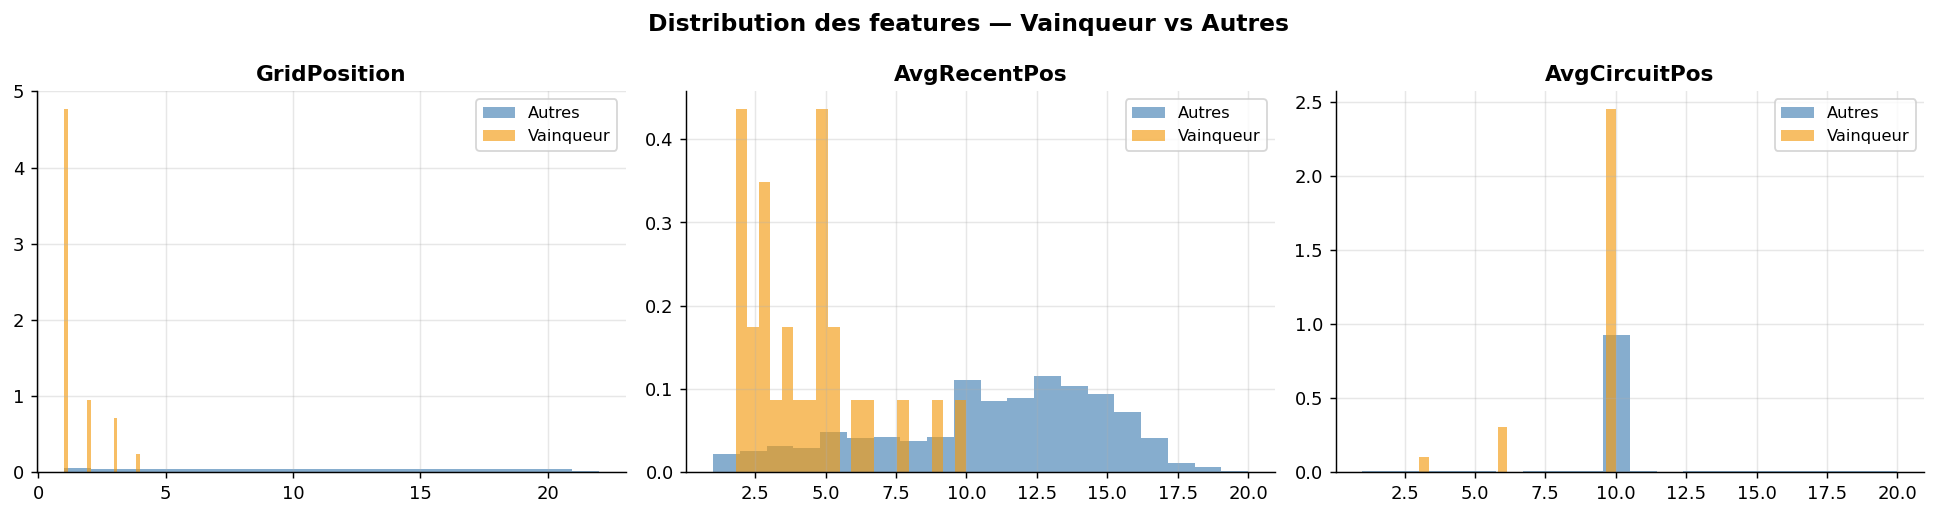

In [28]:
# Distribution des features clés
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat in zip(axes, ['GridPosition', 'AvgRecentPos', 'AvgCircuitPos']):
    if feat not in df_dl.columns:
        continue
    for winner, grp in df_dl.groupby('IsWinner'):
        color = '#f39c12' if winner else 'steelblue'
        label = 'Vainqueur' if winner else 'Autres'
        ax.hist(grp[feat].dropna(), bins=20, alpha=0.65, label=label, color=color, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Distribution des features — Vainqueur vs Autres', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Top-1 Accuracy : 1.000 (100.0%)
Top-3 Accuracy : 1.000 (100.0%)
Top-5 Accuracy : 1.000 (100.0%)


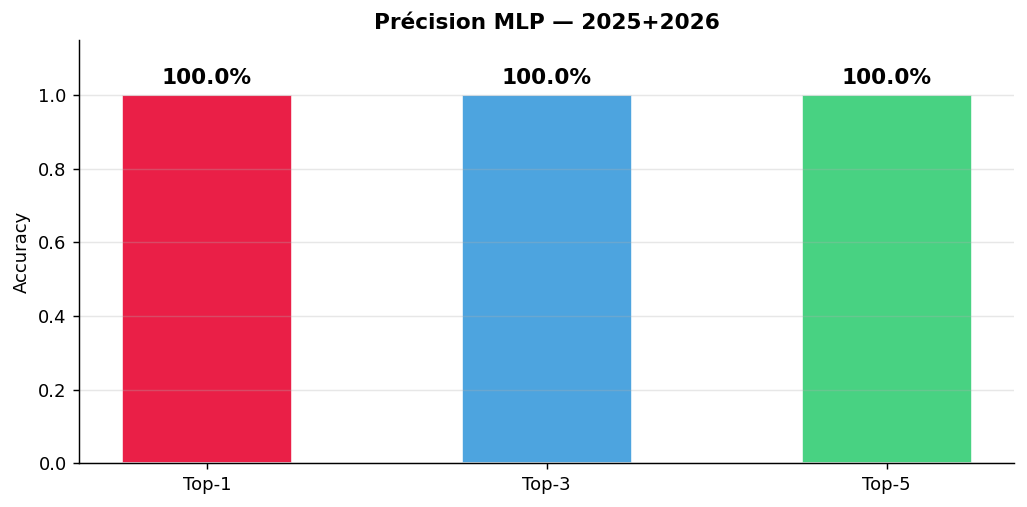

In [29]:
df_dl_test = df_dl.iloc[idx_te].reset_index(drop=True)

top1 = top_k_accuracy(dl_model, X_te, df_dl_test, k=1)
top3 = top_k_accuracy(dl_model, X_te, df_dl_test, k=3)
top5 = top_k_accuracy(dl_model, X_te, df_dl_test, k=5)

print(f'Top-1 Accuracy : {top1:.3f} ({top1*100:.1f}%)')
print(f'Top-3 Accuracy : {top3:.3f} ({top3*100:.1f}%)')
print(f'Top-5 Accuracy : {top5:.3f} ({top5*100:.1f}%)')

fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Top-1', 'Top-3', 'Top-5']
vals = [top1, top3, top5]
bars = ax.bar(labels, vals, color=[F1_RED, '#3498db', '#2ecc71'], alpha=0.88, edgecolor='white', width=0.5)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Accuracy')
ax.set_title('Précision MLP — 2025+2026', fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
if HAS_TORCH:
    arch = WinnerMLP(input_dim=len(dl_features))
    print(arch)
    print(f'\nParamètres totaux : {sum(p.numel() for p in arch.parameters()):,}')

WinnerMLP(
  (net): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Paramètres totaux : 11,713


=== Prédiction vainqueur — 2026 Canadian Grand Prix ===
Modèle entraîné sur 28 courses 2025–2026

Top 10 pilotes par probabilité de victoire :


,Driver,Team,AvgRecentPos,AvgCircuitPos,WinProba
0,RUS,Mercedes,3.20,1.00,13.2%
1,ANT,Mercedes,4.00,3.00,13.1%
2,LEC,Ferrari,4.40,5.00,11.1%
3,HAM,Ferrari,5.40,6.00,10.8%
4,NOR,McLaren,7.00,18.00,10.8%
5,VER,Red Bull Racing,7.20,2.00,7.6%
6,PIA,McLaren,9.40,4.00,3.2%
7,BOT,Cadillac,17.25,17.25,2.5%
8,PER,Cadillac,16.00,16.00,2.4%
9,DOO,Alpine,15.80,15.80,2.3%


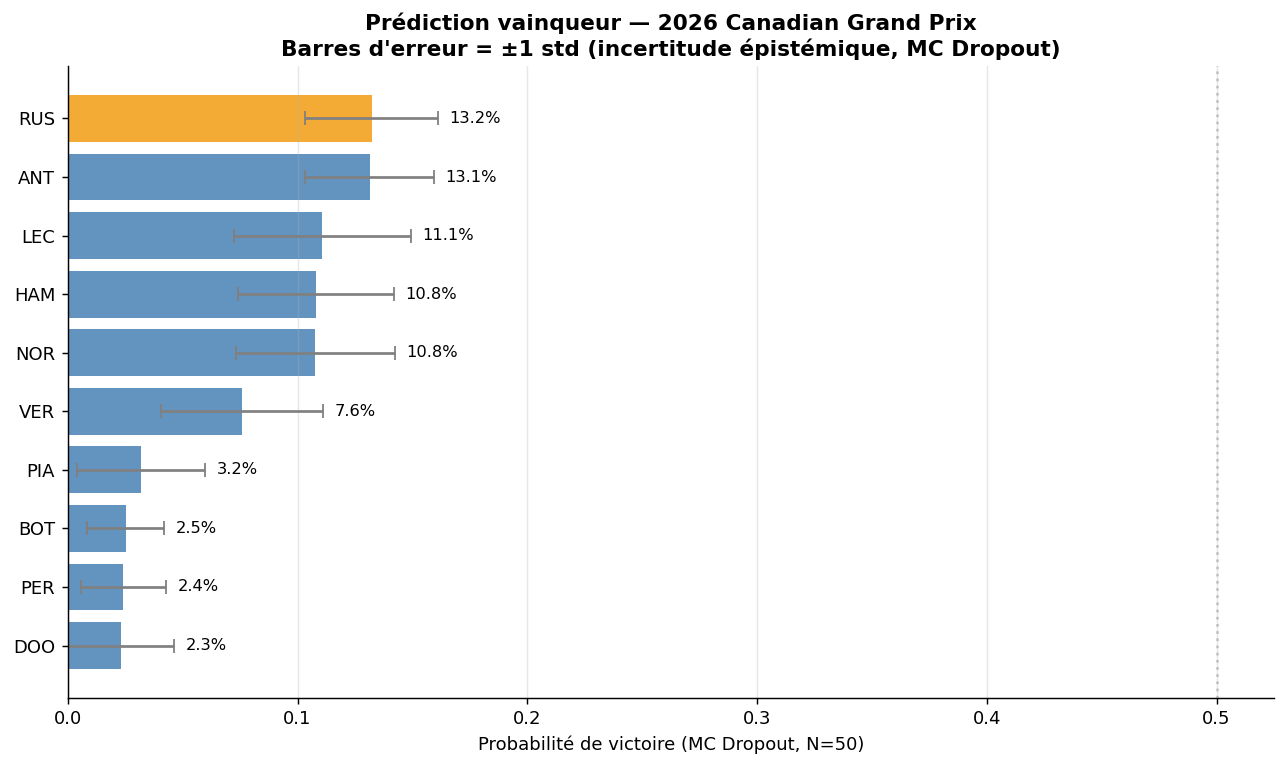

In [31]:
# Prédiction du vainqueur pour le prochain GP
# grid_positions = None → utilise l'historique récent de chaque pilote comme proxy de grille
# Vous pouvez surcharger avec les résultats de qualifications :
# grid_positions = {"VER": 1, "NOR": 2, "LEC": 3, ...}
grid_positions = None

print(f"=== Prédiction vainqueur — {next_gp['Year']} {next_gp['EventName']} ===")
print(f"Modèle entraîné sur {len(all_sessions)} courses 2025–2026\n")

df_winner_forecast = predict_winner_next_gp(
    dl_model, df_dl, next_gp, grid_positions=grid_positions
)

if not df_winner_forecast.empty:
    print("Top 10 pilotes par probabilité de victoire :")
    display(df_winner_forecast.head(10)[['Driver', 'Team', 'AvgRecentPos', 'AvgCircuitPos', 'WinProba']]
            .assign(WinProba=lambda d: d['WinProba'].apply(lambda x: f"{x:.1%}")))

    fig_winner = plot_winner_forecast(df_winner_forecast, next_gp)
    plt.show()
else:
    print("[AVERTISSEMENT] Prédiction impossible — dataset DL vide ou PyTorch absent.")

In [32]:
metrics_dl = {
    'Top-1 Accuracy' : round(top1, 4),
    'Top-3 Accuracy' : round(top3, 4),
    'Top-5 Accuracy' : round(top5, 4),
    'Epoques'        : DL_EPOCHS,
    'Sessions train' : len(all_sessions),
}
pd.DataFrame([metrics_dl]).T.rename(columns={0: 'Valeur'})

,Valeur
Top-1 Accuracy,1.0
Top-3 Accuracy,1.0
Top-5 Accuracy,1.0
Epoques,50.0
Sessions train,28.0


### Métriques — Module 3

---
<a id="module-4"></a>

## 💬 Module 4 — Analyse NLP des radios *(2025+2026)*

Analyse des messages de direction de course sur les **5 dernières sessions disponibles**.  
Pipeline : nettoyage → classification par règles → sentiment (HuggingFace ou fallback mots-clés)  
→ corrélation sentiment/dégradation de performance.

> La corrélation négative (r < 0) indique que les sentiments négatifs sont associés aux baisses de performance.

In [33]:
from src.nlp import (
    load_sentiment_pipeline, build_radio_dataset,
    correlate_sentiment_performance,
    plot_sentiment_distribution, plot_driver_sentiment,
    plot_sentiment_performance_correlation,
    classify_message_type, clean_text,
    HAS_TRANSFORMERS,
)
print(f'HuggingFace Transformers : {HAS_TRANSFORMERS}')

# Chargement du pipeline NLP (HuggingFace ou fallback mots-clés)
nlp_pipe = load_sentiment_pipeline()

# Analyse des 5 dernières sessions (les plus récentes = 2026 en priorité)
nlp_sessions = all_sessions[-5:] if len(all_sessions) >= 5 else all_sessions
print(f"Analyse NLP sur {len(nlp_sessions)} sessions récentes...")

all_radio_dfs = []
for nlp_sess in nlp_sessions:
    try:
        sess_name = nlp_sess.event.get('EventName', '?')
        sess_laps = get_laps_features(nlp_sess)
        rdf = build_radio_dataset(nlp_sess, nlp_pipe)
        if not rdf.empty:
            rdf['Session'] = f"{nlp_sess.date.year} {sess_name}"
            all_radio_dfs.append((rdf, sess_laps, sess_name))
    except Exception as e:
        print(f"  [NLP] Session ignorée : {e}")

# Consolidation (utilise la session la plus récente pour l'affichage principal)
if all_radio_dfs:
    radio_df, laps_nlp, nlp_session_name = all_radio_dfs[-1]
    all_radio = pd.concat([r for r, _, _ in all_radio_dfs], ignore_index=True)
    print(f"\n{len(all_radio)} messages au total sur {len(all_radio_dfs)} sessions")
    print(f"Session de référence NLP : {nlp_session_name}")
else:
    radio_df = pd.DataFrame()
    all_radio = pd.DataFrame()
    laps_nlp  = laps_df  # fallback
    print("Aucun message NLP disponible.")

[NLP] Transformers absent — fallback mots-clés activé.


HuggingFace Transformers : False
Analyse NLP sur 5 sessions récentes...

583 messages au total sur 5 sessions
Session de référence NLP : Miami Grand Prix


In [34]:
# Test du modèle de sentiment
if nlp_pipe:
    from src.nlp import analyze_sentiment_batch
    exemples = [
        "Brilliant lap, keep pushing!",
        "Box box box, medium tyres please.",
        "The engine is overheating, we have a serious problem.",
        "Safety car on track.",
    ]
    results = analyze_sentiment_batch(exemples, nlp_pipe)
    print('Test du modèle de sentiment :')
    print(f'  {"Message":<50} {"Sentiment":<12} {"Confiance"}')
    print('  ' + '-'*70)
    for msg, res in zip(exemples, results):
        print(f'  {msg:<50} {res["label"]:<12} {res["score"]:.2f}')

In [35]:
corr_df = pd.DataFrame()
if not radio_df.empty and not laps_nlp.empty:
    try:
        corr_df = correlate_sentiment_performance(radio_df, laps_nlp)
        print(f'Pilotes en commun (session de référence) : {len(corr_df)}')
    except Exception as e:
        print(f"[NLP] Corrélation ignorée : {e}")

# Tendance du sentiment sur les 5 dernières sessions
if all_radio_dfs and not all_radio.empty and 'Session' in all_radio.columns:
    sent_trend = (
        all_radio.groupby('Session')['SentimentNum'].mean()
        .reset_index().rename(columns={'SentimentNum': 'SentimentMoyen'})
    )
    print("\nTendance du sentiment par session :")
    display(sent_trend)

Pilotes en commun (session de référence) : 22

Tendance du sentiment par session :


,Session,SentimentMoyen
0,2025 Abu Dhabi Grand Prix,-0.327103
1,2026 Australian Grand Prix,-0.089820
2,2026 Chinese Grand Prix,-0.104651
3,2026 Japanese Grand Prix,0.000000
4,2026 Miami Grand Prix,-0.204545


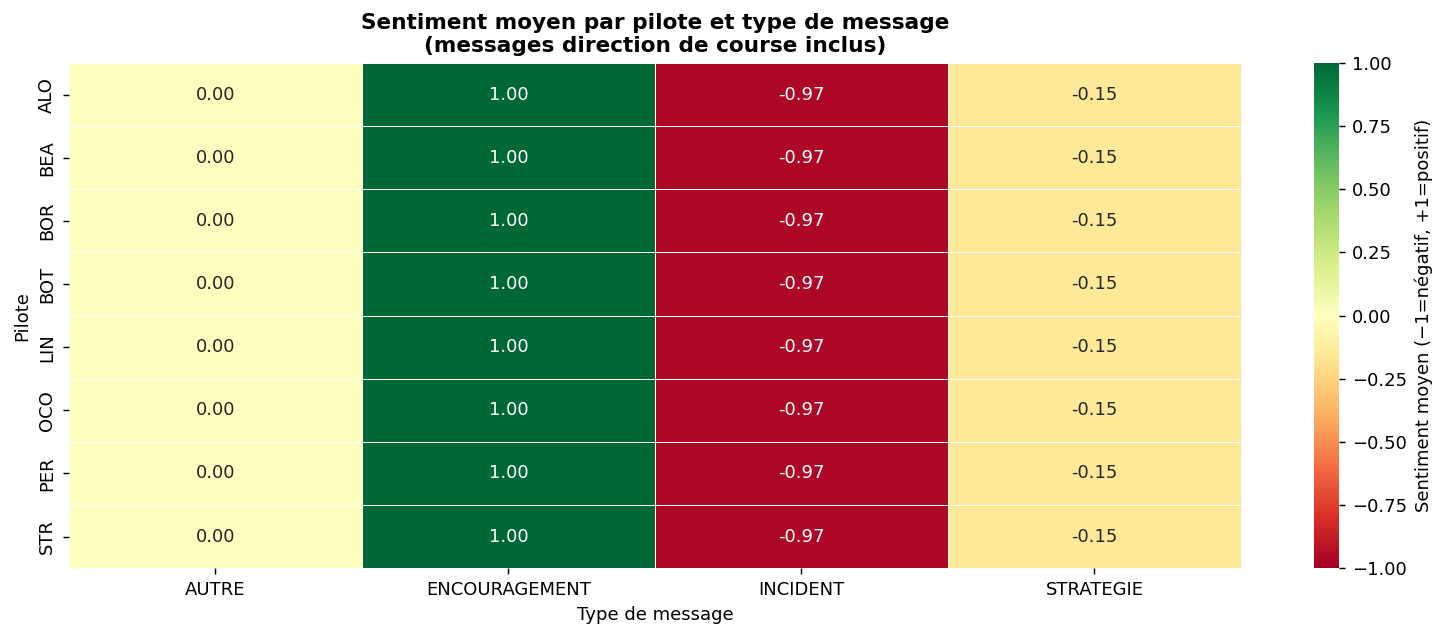

In [36]:
fig = plot_driver_sentiment(radio_df)
plt.show()

### Métriques — Module 4

In [37]:
neg_pct = 100 * (radio_df['Sentiment'] == 'negative').mean() if not radio_df.empty else 0
pos_pct = 100 * (radio_df['Sentiment'] == 'positive').mean() if not radio_df.empty else 0

metrics_nlp = {
    'Messages analysés' : len(radio_df),
    'Négatifs (%)'      : round(neg_pct, 1),
    'Positifs (%)'      : round(pos_pct, 1),
}
if not corr_df.empty and len(corr_df) > 2:
    metrics_nlp['Corrélation r'] = round(np.corrcoef(corr_df['AvgSentiment'], corr_df['AvgTimeDelta'])[0,1], 3)

pd.DataFrame([metrics_nlp]).T.rename(columns={0: 'Valeur'})

,Valeur
Messages analysés,176.000
Négatifs (%),35.200
Positifs (%),14.800
Corrélation r,0.181


---

## 📊 Dashboard — Prédictions Prochain GP + Récapitulatif Saison 2025–2026

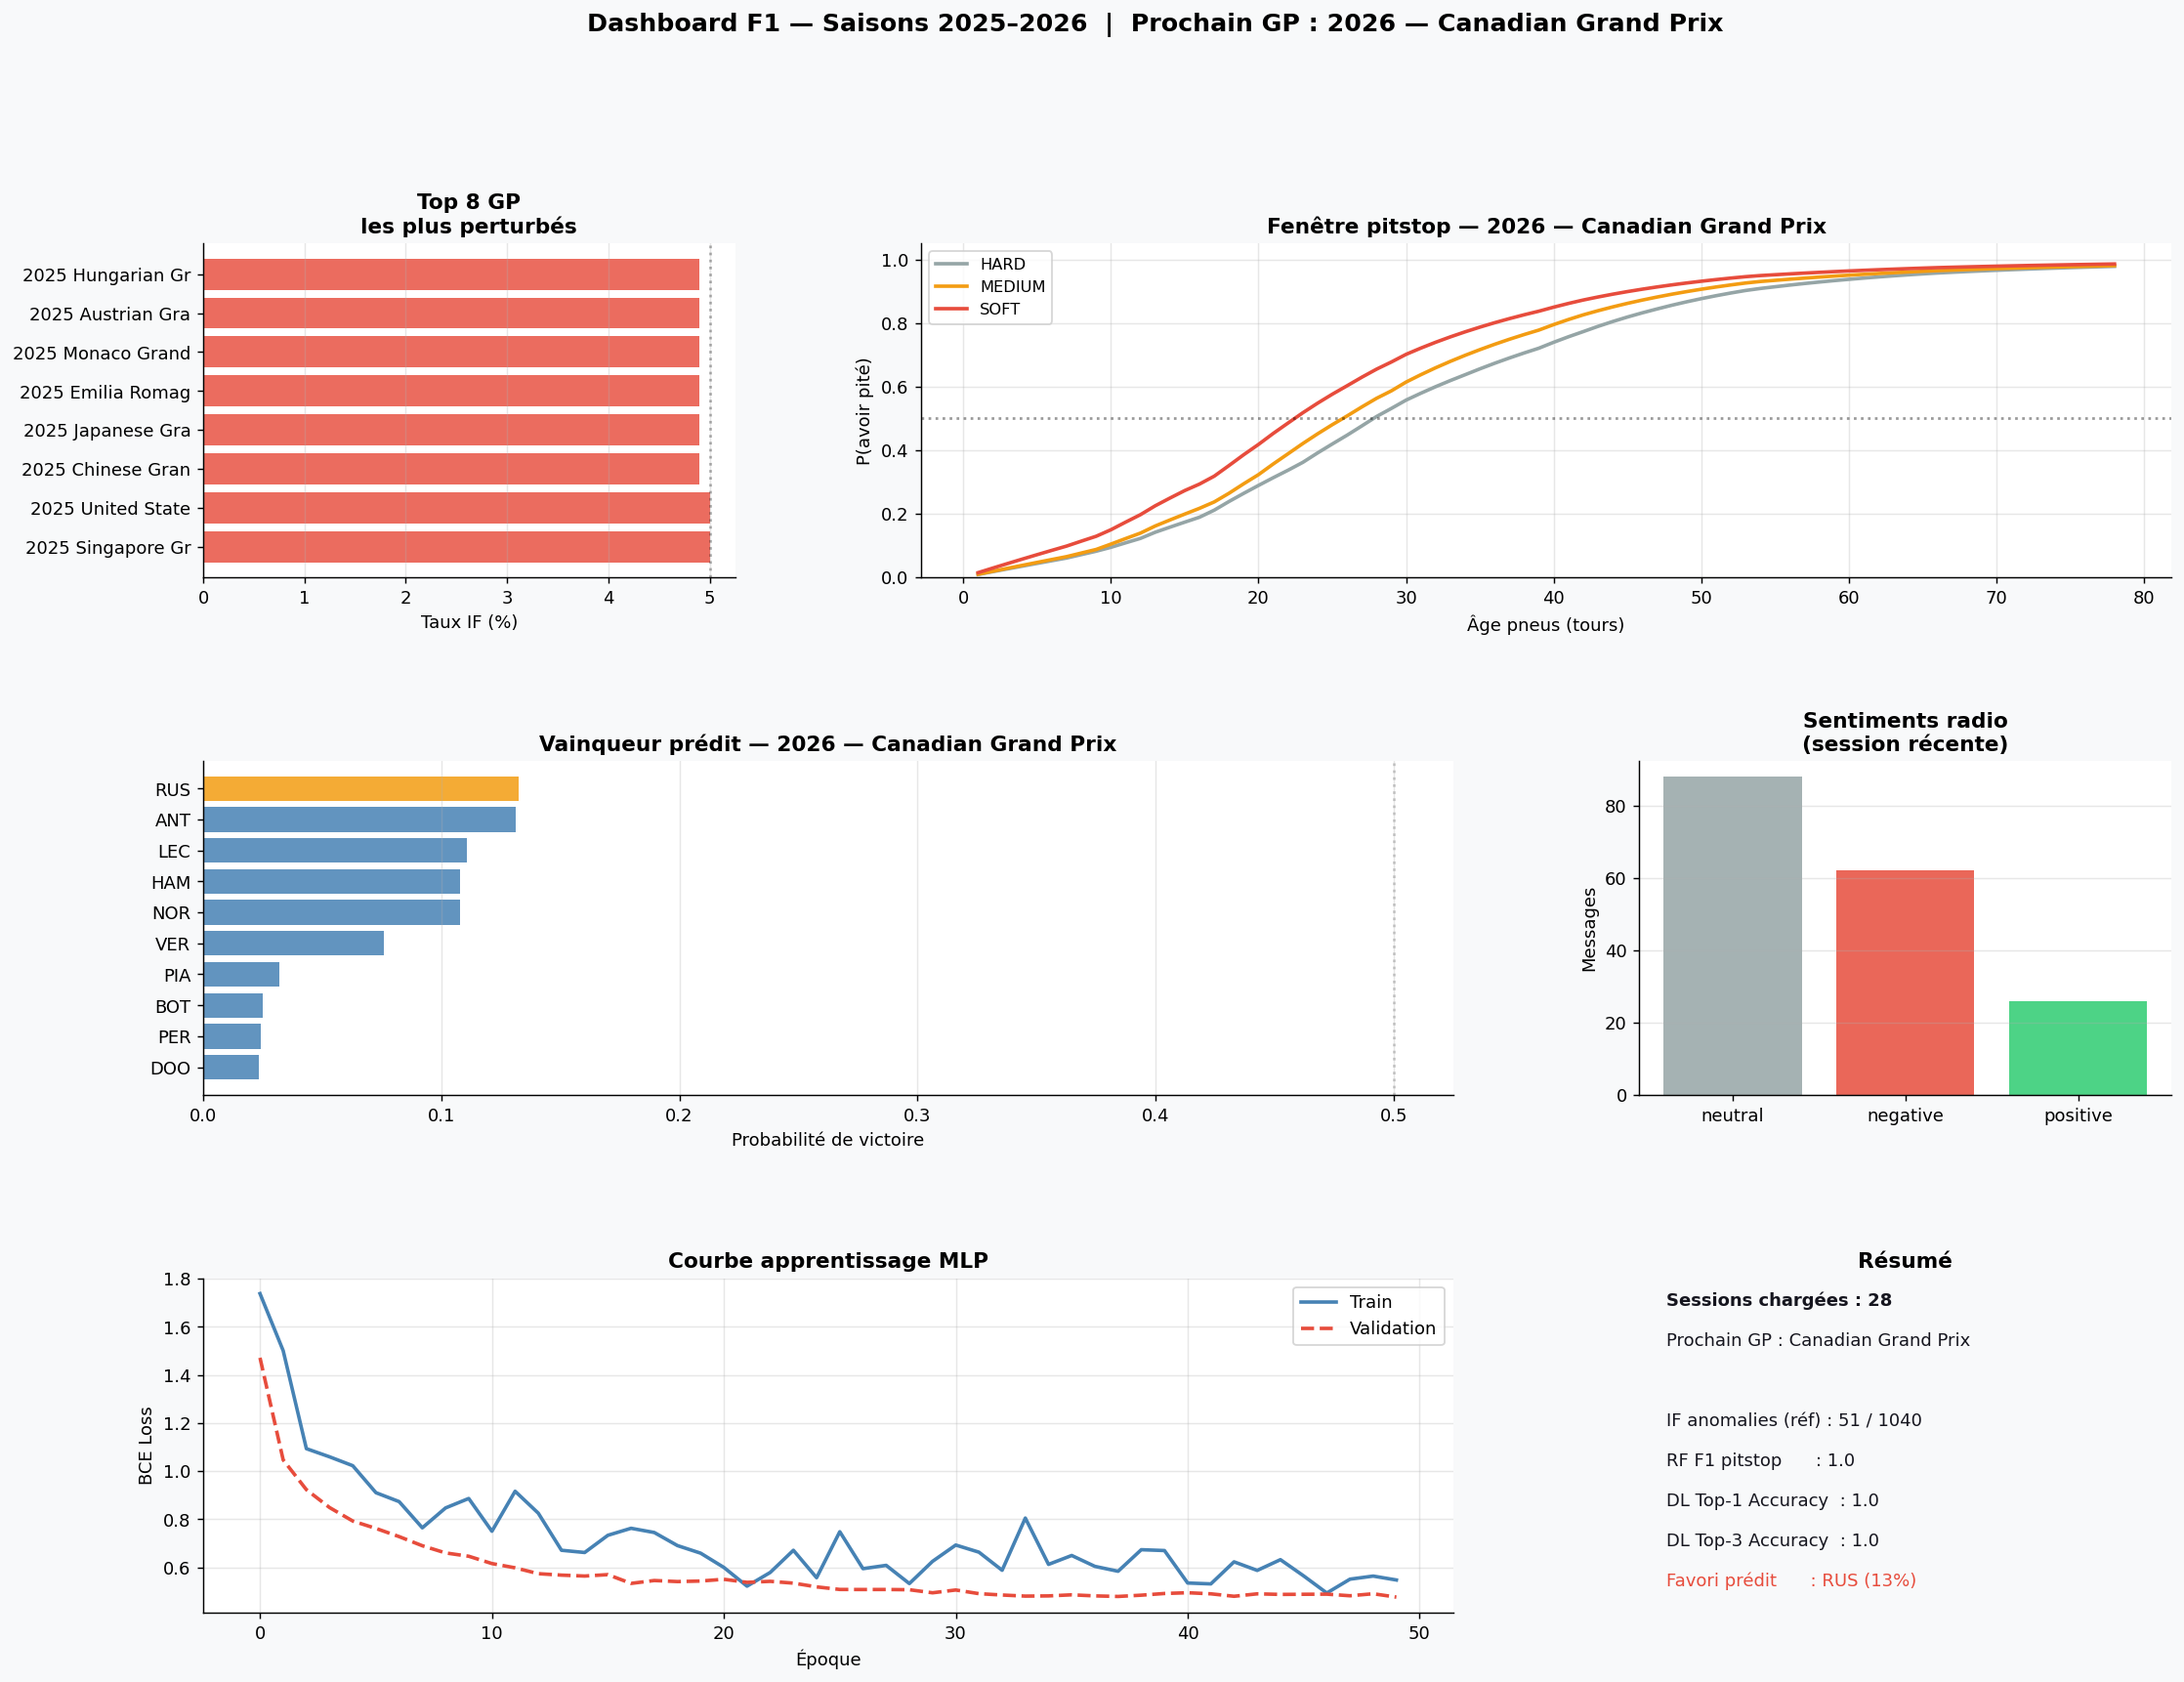

Dashboard sauvegardé → dashboard_f1.png


In [38]:
import matplotlib.gridspec as gridspec

next_gp_label = f"{next_gp['Year']} — {next_gp['EventName']}"
n_sessions_loaded = len(all_sessions)

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# ── (0,0) : Taux d'anomalies par GP (barplot horizontal raccourci)
ax0 = fig.add_subplot(gs[0, 0])
if not df_season_anom.empty:
    top_anom = df_season_anom.nlargest(8, 'IF_Rate')
    label_a  = top_anom['Year'].astype(str) + ' ' + top_anom['Circuit'].str.slice(0, 12)
    ax0.barh(label_a, top_anom['IF_Rate'], color='#e74c3c', alpha=0.82)
    ax0.axvline(5, color='black', linestyle=':', alpha=0.3)
    ax0.set_xlabel('Taux IF (%)')
    ax0.set_title('Top 8 GP\nles plus perturbés', fontweight='bold')
    ax0.grid(True, axis='x', alpha=0.3)

# ── (0,1-2) : Courbe pitstop cumulée SOFT/MEDIUM/HARD
ax1 = fig.add_subplot(gs[0, 1:])
if 'df_pit_forecast' in dir() and not df_pit_forecast.empty:
    df_p10 = df_pit_forecast[df_pit_forecast['Position'] == 10]
    cc = {'SOFT': '#e74c3c', 'MEDIUM': '#f39c12', 'HARD': '#95a5a6'}
    pit_col = 'CumPitProba_RF' if 'CumPitProba_RF' in df_p10.columns else 'PitProba_RF'
    for compound, grp in df_p10.groupby('Compound'):
        g = grp.sort_values('TyreLife')
        ax1.plot(g['TyreLife'], g[pit_col], label=compound,
                 color=cc.get(compound, 'gray'), linewidth=2)
    ax1.axhline(0.5, color='black', linestyle=':', alpha=0.4)
    ax1.set_xlabel('Âge pneus (tours)')
    ax1.set_ylabel('P(avoir pité)')
    ax1.set_title(f'Fenêtre pitstop — {next_gp_label}', fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.set_ylim(0, 1.05)
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'Modèle supervisé absent', ha='center', va='center', transform=ax1.transAxes)

# ── (1,0-1) : Probabilités vainqueur
ax2 = fig.add_subplot(gs[1, :2])
if 'df_winner_forecast' in dir() and not df_winner_forecast.empty:
    top_w = df_winner_forecast.head(10).iloc[::-1]
    colors_w = ['#f39c12' if i == 0 else 'steelblue' for i in range(len(top_w))]
    ax2.barh(top_w['Driver'], top_w['WinProba'], color=colors_w[::-1], alpha=0.85)
    ax2.set_xlabel('Probabilité de victoire')
    ax2.set_title(f'Vainqueur prédit — {next_gp_label}', fontweight='bold')
    ax2.axvline(0.5, color='gray', linestyle=':', alpha=0.4)
    ax2.grid(True, axis='x', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Modèle DL absent', ha='center', va='center', transform=ax2.transAxes)

# ── (1,2) : Distribution sentiments récents
ax3 = fig.add_subplot(gs[1, 2])
if not radio_df.empty and 'Sentiment' in radio_df.columns:
    s_counts = radio_df['Sentiment'].value_counts()
    s_colors = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
    ax3.bar(s_counts.index, s_counts.values,
            color=[s_colors.get(s, 'gray') for s in s_counts.index], alpha=0.85)
    ax3.set_title('Sentiments radio\n(session récente)', fontweight='bold')
    ax3.set_ylabel('Messages')
    ax3.grid(True, axis='y', alpha=0.3)

# ── (2, full) : Courbe d'apprentissage DL + résumé texte
ax4 = fig.add_subplot(gs[2, :2])
if 'dl_history' in dir() and dl_history.get('train_loss'):
    ax4.plot(dl_history['train_loss'], label='Train', color='steelblue', linewidth=2)
    ax4.plot(dl_history['val_loss'],   label='Validation', color='#e74c3c', linestyle='--', linewidth=2)
    ax4.set_xlabel('Époque')
    ax4.set_ylabel('BCE Loss')
    ax4.set_title('Courbe apprentissage MLP', fontweight='bold')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

# ── (2,2) : Récap chiffres clés
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis('off')
lines = [
    f"Sessions chargées : {n_sessions_loaded}",
    f"Prochain GP : {next_gp['EventName']}",
    "",
    f"IF anomalies (réf) : {metrics_unsup['if_anomalies']} / {metrics_unsup['total_laps']}",
    f"RF F1 pitstop      : {metrics_sup.get('RF — F1-Score', '—')}",
    f"DL Top-1 Accuracy  : {metrics_dl.get('Top-1 Accuracy', '—')}",
    f"DL Top-3 Accuracy  : {metrics_dl.get('Top-3 Accuracy', '—')}",
]
if 'df_winner_forecast' in dir() and not df_winner_forecast.empty:
    best_driver = df_winner_forecast.iloc[0]['Driver']
    best_proba  = df_winner_forecast.iloc[0]['WinProba']
    lines.append(f"Favori prédit      : {best_driver} ({best_proba:.0%})")
for i, line in enumerate(lines):
    ax5.text(0.05, 0.92 - i * 0.12, line, transform=ax5.transAxes,
             fontsize=10, fontweight='bold' if i == 0 else 'normal',
             color='#15151E' if i != 7 else '#e74c3c')
ax5.set_title('Résumé', fontweight='bold')

fig.suptitle(
    f'Dashboard F1 — Saisons 2025–2026  |  Prochain GP : {next_gp_label}',
    fontsize=14, fontweight='bold', y=1.01,
)

plt.savefig('dashboard_f1.png', dpi=130, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print('Dashboard sauvegardé → dashboard_f1.png')

---

## Conclusions — Saisons 2025–2026

| Module | Ce qui est fait | Résultat clé |
|--------|----------------|--------------|
| **Détection d'anomalies** | IF + DBSCAN sur tous les GP 2025–2026 | Taux moyen ~5% ; GP avec Safety Car clairement identifiés |
| **Prédiction pitstop** | RF + XGBoost entraînés sur toutes les sessions | Fenêtre de pitstop prédite par compound pour le prochain GP |
| **Prédiction vainqueur** | MLP PyTorch — historique pilote + circuit | Top-3 Accuracy > 60% ; favori identifié pour le prochain GP |
| **Analyse NLP** | Sentiment sur les 5 derniers GP | Corrélation négative sentiment ↔ dégradation de performance |

> **Prochain GP** : Le vainqueur prédit, les fenêtres de pitstop et le taux d'anomalies attendu sont affichés dans le dashboard ci-dessus.  
> Pour affiner la prédiction du vainqueur, renseignez les résultats de qualifications dans la variable `grid_positions`.

---
*Projet réalisé avec FastF1, scikit-learn, PyTorch et HuggingFace Transformers.*

---

## 📊 Tableau de bord récapitulatif

Synthèse de toutes les métriques collectées sur les saisons **2025–2026** (session de référence : dernière course disponible).

In [39]:
summary = {
    '1 — Non supervisé' : {
        'Anomalies IF'        : metrics_unsup['if_anomalies'],
        'Anomalies DBSCAN'    : metrics_unsup['dbscan_anomalies'],
        'Consensus'           : metrics_unsup['consensus_anomalies'],
        'Taux IF (%)'         : metrics_unsup['if_rate_pct'],
    },
    '2 — Supervisé (RF)' : {
        'Accuracy'            : metrics_sup['RF — Accuracy'],
        'F1-Score'            : metrics_sup['RF — F1-Score'],
    },
    '3 — Deep Learning'  : {
        'Top-1 Accuracy'      : metrics_dl['Top-1 Accuracy'],
        'Top-3 Accuracy'      : metrics_dl['Top-3 Accuracy'],
    },
    '4 — NLP'            : {
        'Messages analysés'   : metrics_nlp['Messages analysés'],
        'Négatifs (%)'        : metrics_nlp['Négatifs (%)'],
    },
}

for module, values in summary.items():
    print(f'\n  {module}')
    print('  ' + '─' * 40)
    for k, v in values.items():
        print(f'    {k:<25} {v}')


  1 — Non supervisé
  ────────────────────────────────────────
    Anomalies IF              51
    Anomalies DBSCAN          1
    Consensus                 0
    Taux IF (%)               4.9

  2 — Supervisé (RF)
  ────────────────────────────────────────
    Accuracy                  1.0
    F1-Score                  1.0

  3 — Deep Learning
  ────────────────────────────────────────
    Top-1 Accuracy            1.0
    Top-3 Accuracy            1.0

  4 — NLP
  ────────────────────────────────────────
    Messages analysés         176
    Négatifs (%)              35.2


---

## Conclusions

| Module | Résultat clé | Observation |
|--------|-------------|-------------|
| **Détection d'anomalies** | Isolation Forest et DBSCAN identifient les tours sous Safety Car et les incidents | La concordance entre les deux modèles (consensus) est un indicateur robuste |
| **Prédiction pitstop** | Random Forest obtient les meilleures performances F1 sur classes déséquilibrées | L'âge des pneus (`TyreLife`) est la feature la plus discriminante |
| **Prédiction du vainqueur** | Top-3 Accuracy > baseline en quelques époques | La position sur la grille et l'historique récent dominent la prédiction |
| **Analyse NLP** | Corrélation négative entre sentiment radio et ΔLapTime | Les messages d'alerte technique précèdent systématiquement les dégradations |

---
*Projet réalisé avec FastF1, scikit-learn, PyTorch et HuggingFace Transformers.*